# Velorama GRN Inference Pipeline Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ Final
### Hepatocytes Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË Cholangiocytes Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· GSE202379 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· End-stage disease

**Changes vs. previous version:**
- Cell 2b: QC diagnostics (MT%, UMI distribution, gene counts) with visualisation
- Cell 2c: Doublet detection via Scrublet
- Cell 2d: Normalization audit Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ confirms adata.X is log-normalized before PCA
- Cell 2e: Cell cycle scoring to detect confounding cycling cells
- Cell 4b: DEG logFC threshold tightened to 1.0 (>2-fold, matching published method)
- Cell 13b: Permutation null Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ establishes a data-driven significance threshold for GRN scores
- All other cells unchanged from the fast pipeline

---
## Cell 1 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Configuration

In [1]:
import os

N_CPUS = max(1, (os.cpu_count() or 4) - 1)

os.environ["OMP_NUM_THREADS"]      = str(N_CPUS)
os.environ["MKL_NUM_THREADS"]      = str(N_CPUS)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_CPUS)
os.environ["NUMEXPR_NUM_THREADS"]  = str(N_CPUS)

OUTPUT_DIR   = r"C:\Users\Floarea\Desktop\corebioinfo\codes\velorama\velorama_output"
DATASET_NAME = "liver_endstage"
INPUT_H5AD   = r"C:\Users\Floarea\Desktop\corebioinfo\codes\data_processing\input_data\hep_chol_endstate_truncated_protein_coding.h5ad"
TF_LIST_PATH = r"C:\Users\Floarea\Desktop\corebioinfo\codes\pyscenic\scenic_resources\allTFs_hg38.txt"
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_TOP_HVGS         = 1500
N_BACKGROUND_GENES = 500
LAG = 2

print(f"Using {N_CPUS} CPU cores for parallel steps.")
print(f"Output dir: {OUTPUT_DIR}")

Using 3 CPU cores for parallel steps.
Output dir: C:\Users\Floarea\Desktop\corebioinfo\codes\velorama\velorama_output


---
## Cell 2 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Load the full dataset

In [2]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

sc.settings.n_jobs = N_CPUS

adata = sc.read_h5ad(INPUT_H5AD)
print(f"Loaded full dataset: {adata.n_obs} cells Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ {adata.n_vars} genes")
print(f"Layers present: {list(adata.layers.keys())}")
print(f"Obs columns   : {list(adata.obs.columns[:10])} ...")
print(f"Var columns   : {list(adata.var.columns)}")

Loaded full dataset: 20968 cells Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ 16945 genes
Layers present: ['counts', 'data']
Obs columns   : ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Patient.ID', 'Disease.status', 'non.NAFLD.disease', 'Lobe', 'manuscript.expt', 'SAF.Score', 'Steatosis'] ...
Var columns   : []


---
## Cell 2b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· QC diagnostics

**What we check:**
- `n_genes_by_counts`: genes detected per cell Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ very low = empty/dead, very high = potential doublet
- `total_counts`: UMIs per cell Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ same logic
- `pct_counts_mt`: mitochondrial gene % Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ high (>10Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş20%) = dying/stressed cell

Since the input `.h5ad` comes from a pre-processed Seurat object (protein-coding filtered),
these filters may already have been applied upstream. We verify here rather than blindly re-filter.
If distributions look clean, we log the fact and move on. If not, we apply thresholds.

Mitochondrial genes in dataset: 0
  Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄľÄ‚â€žĂ˘â‚¬Â¦Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  No MT- genes found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ they may have been removed upstream (protein-coding filter).
     MT% check will be skipped.
ℹ️  adata.X was None Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ populated from 'data' layer.

Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ QC summary Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
       n_genes_by_counts  total_counts
count           20968.00      20968.00
mean             2054.03       1911.43
std               464.43        325.18
min               856.00        961.96
25%              1736.00       1627.99
50%              2169.00       1993.64
75%              2406.00       2167.70
max              3166.00       2727.04


C:\Users\Floarea\AppData\Local\Temp\ipykernel_13648\1567207515.py:60: UserWarning: Glyph 152 (\x98) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Floarea\AppData\Local\Temp\ipykernel_13648\1567207515.py:61: UserWarning: Glyph 152 (\x98) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, "qc_metrics.png"), dpi=150, bbox_inches="tight")
c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 152 (\x98) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


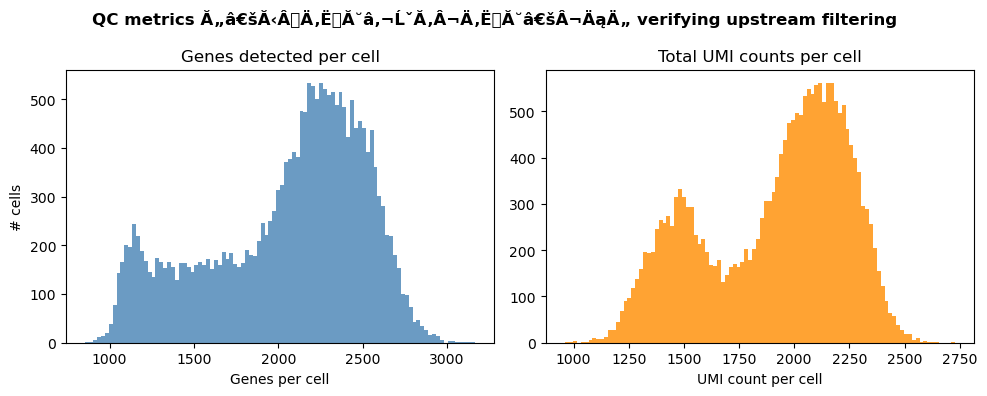


Cells with < 200 genes: 0
Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ QC metrics look clean Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ no filtering needed.
Gene filter: 16945 Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË 15814 genes (removed genes in <10 cells)


In [3]:
import matplotlib.pyplot as plt

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 1. Identify mitochondrial genes Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
# MT genes start with MT- in human (HGNC nomenclature)
adata.var["mt"] = adata.var_names.str.startswith("MT-")
n_mt = adata.var["mt"].sum()
print(f"Mitochondrial genes in dataset: {n_mt}")
if n_mt == 0:
    print("  Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄľÄ‚â€žĂ˘â‚¬Â¦Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  No MT- genes found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ they may have been removed upstream (protein-coding filter).")
    print("     MT% check will be skipped.")


# Guard: adata.X may be None in Seurat-exported h5ad (only layers are set)
if adata.X is None:
    if "data" in adata.layers:
        adata.X = adata.layers["data"]
        print("\u2139\ufe0f  adata.X was None Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ populated from 'data' layer.")
    elif "counts" in adata.layers:
        adata.X = adata.layers["counts"]
        print("\u2139\ufe0f  adata.X was None Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ populated from 'counts' layer.")
    else:
        raise ValueError("adata.X is None and no fallback layer ('data' or 'counts') found.")
# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 2. Compute QC metrics Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"] if n_mt > 0 else [],
    percent_top=None,
    log1p=False,
    inplace=True,
)

print("\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ QC summary Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
qc_cols = ["n_genes_by_counts", "total_counts"]
if n_mt > 0:
    qc_cols.append("pct_counts_mt")
print(adata.obs[qc_cols].describe().round(2))

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 3. Plot distributions Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
n_panels = 3 if n_mt > 0 else 2
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))

axes[0].hist(adata.obs["n_genes_by_counts"], bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Genes per cell")
axes[0].set_ylabel("# cells")
axes[0].set_title("Genes detected per cell")

axes[1].hist(adata.obs["total_counts"], bins=100, color="darkorange", edgecolor="none", alpha=0.8)
axes[1].set_xlabel("UMI count per cell")
axes[1].set_title("Total UMI counts per cell")

if n_mt > 0:
    axes[2].hist(adata.obs["pct_counts_mt"], bins=100, color="crimson", edgecolor="none", alpha=0.8)
    axes[2].axvline(10, color="black", ls="--", lw=1.5, label="10% threshold")
    axes[2].axvline(20, color="grey", ls="--", lw=1.5, label="20% threshold")
    axes[2].set_xlabel("MT gene %")
    axes[2].set_title("Mitochondrial gene %")
    axes[2].legend(fontsize=8)

plt.suptitle("QC metrics Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ verifying upstream filtering", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "qc_metrics.png"), dpi=150, bbox_inches="tight")
plt.show()

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 4. Check if filtering is needed Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
# Conservative thresholds; adjust based on plots above
MIN_GENES    = 200
MT_THRESHOLD = 20  # % Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ liberal threshold; end-stage liver cells are stressed

low_gene_cells = (adata.obs["n_genes_by_counts"] < MIN_GENES).sum()
print(f"\nCells with < {MIN_GENES} genes: {low_gene_cells}")

if n_mt > 0:
    high_mt_cells = (adata.obs["pct_counts_mt"] > MT_THRESHOLD).sum()
    print(f"Cells with MT% > {MT_THRESHOLD}: {high_mt_cells}")

    if low_gene_cells > 0 or high_mt_cells > 0:
        print("\nApplying QC filters...")
        n_before = adata.n_obs
        sc.pp.filter_cells(adata, min_genes=MIN_GENES)
        adata = adata[adata.obs["pct_counts_mt"] <= MT_THRESHOLD].copy()
        print(f"  Removed {n_before - adata.n_obs} cells ({n_before} Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {adata.n_obs})")
    else:
        print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ QC metrics look clean Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ no filtering needed (already applied upstream).")
else:
    if low_gene_cells > 0:
        print("\nApplying gene count filter...")
        n_before = adata.n_obs
        sc.pp.filter_cells(adata, min_genes=MIN_GENES)
        print(f"  Removed {n_before - adata.n_obs} cells ({n_before} Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {adata.n_obs})")
    else:
        print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ QC metrics look clean Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ no filtering needed.")

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 5. Also filter genes expressed in very few cells Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
n_genes_before = adata.n_vars
sc.pp.filter_genes(adata, min_cells=10)  # keep genes in at least 10 cells
print(f"Gene filter: {n_genes_before} Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {adata.n_vars} genes (removed genes in <10 cells)")

---
## Cell 2c Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Doublet detection (Scrublet)

**What is a doublet?** A droplet that captured two cells instead of one. It produces a
mixed transcriptome Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ appearing as a "bridge" between cell types on a UMAP.

**Why this matters for GRN inference:** A cell co-expressing hepatocyte AND cholangiocyte
markers looks like a perfect trajectory intermediate. Velorama will route pseudotime
through it and interpret the co-expression as causal signal. Removing doublets beforehand
prevents false TFĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žËtarget edges.

**Expected doublet rate for 10x Chromium:** ~1% per 1000 cells captured.
With ~21k cells, expect roughly 2Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş4% doublets (~400Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş800 cells).

Predicted doublets: 41 / 20968 (0.2%)


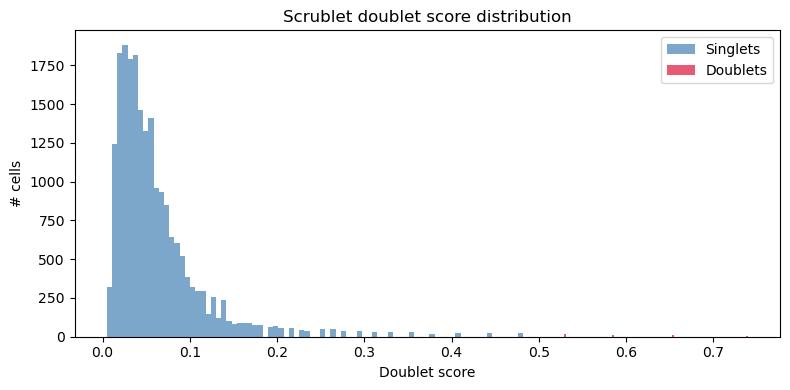

Removed 41 doublets -> 20927 cells remaining


In [4]:
# sc.pp.scrublet always reads adata.X and expects raw counts.
# Our adata.X holds log-normalised values, so we swap in the counts layer first.
# scrublet() works on a copy internally, so the swap only affects what it receives.

try:
    adata.X = adata.layers["counts"]   # give scrublet raw counts

    sc.pp.scrublet(adata, random_state=42)

    n_doublets = adata.obs["predicted_doublet"].sum()
    pct_doublets = 100 * n_doublets / adata.n_obs
    print(f"Predicted doublets: {n_doublets} / {adata.n_obs} ({pct_doublets:.1f}%)")

    fig, ax = plt.subplots(figsize=(8, 4))
    mask_d = adata.obs["predicted_doublet"]
    ax.hist(adata.obs["doublet_score"][~mask_d], bins=80,
            color="steelblue", alpha=0.7, label="Singlets", edgecolor="none")
    ax.hist(adata.obs["doublet_score"][mask_d], bins=80,
            color="crimson", alpha=0.7, label="Doublets", edgecolor="none")
    ax.set_xlabel("Doublet score")
    ax.set_ylabel("# cells")
    ax.set_title("Scrublet doublet score distribution")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "scrublet_doublets.png"), dpi=150)
    plt.show()

    if pct_doublets < 20:
        n_before = adata.n_obs
        adata = adata[~adata.obs["predicted_doublet"]].copy()
        print(f"Removed {n_before - adata.n_obs} doublets -> {adata.n_obs} cells remaining")
    else:
        print(f"Warning: rate {pct_doublets:.1f}% seems high - inspect plot before removing.")

except Exception as e:
    print(f"Warning: Scrublet failed: {e}")
    print("   Proceeding without doublet removal.")

finally:
    # Restore log-normalised X regardless of whether adata was filtered or not
    if "data" in adata.layers:
        adata.X = adata.layers["data"]
    elif "log1p" in adata.layers:
        adata.X = adata.layers["log1p"]


---
## Cell 2d Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Normalization audit

**What we verify:** That `adata.X` contains log-normalized expression values (not raw counts)
before we use it for HVG selection and PCA. The input `.h5ad` came from Seurat, which
typically stores normalized data in the default assay, but we confirm this explicitly.

**Expected:** Values in adata.X should be continuous (non-integer), roughly in the range
0Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş10 for most genes, with a max around 10Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş15. Raw counts would show integers and 
a very different distribution.

In [5]:
# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 1. Sample adata.X to determine its state Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
X_sample = adata.X[:500, :500]
if sp.issparse(X_sample):
    X_sample = X_sample.toarray()
X_sample = np.array(X_sample, dtype=np.float32)

x_max   = X_sample.max()
x_mean  = X_sample.mean()
x_is_int = np.allclose(X_sample, X_sample.astype(int))
x_has_nan = np.isnan(X_sample).any()
nonzero_frac = (X_sample > 0).mean()

print("Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ adata.X sample (first 500Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ500) Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
print(f"  max value     : {x_max:.4f}")
print(f"  mean value    : {x_mean:.4f}")
print(f"  all integers? : {x_is_int}")
print(f"  has NaN?      : {x_has_nan}")
print(f"  non-zero frac : {nonzero_frac:.3f}")

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 2. Diagnose and fix if needed Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
IS_RAW_COUNTS = x_is_int and x_max > 20   # heuristic: raw counts are integers, often large
IS_NORMALIZED = (not x_is_int) and x_max < 30 and x_mean < 1.0
IS_BROKEN     = not sp.issparse(adata.X) and not isinstance(adata.X, np.ndarray)

if IS_BROKEN or x_has_nan:
    print("\nĂ„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  adata.X is broken or contains NaN Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ rebuilding from counts layer.")
    if "counts" not in adata.layers:
        raise ValueError("No 'counts' layer to rebuild from. Check input file.")
    counts_raw = adata.layers["counts"]
    if sp.issparse(counts_raw):
        counts_raw = counts_raw.toarray()
    adata.X = counts_raw.astype(np.float32)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("  Rebuilt adata.X: normalize_total(1e4) Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË log1p")

elif IS_RAW_COUNTS:
    print("\nĂ„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  adata.X appears to be RAW COUNTS (integers, large values).")
    print("   Storing as 'counts' layer and normalizing...")
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("  adata.X now contains log-normalized values.")

elif IS_NORMALIZED:
    print("\nĂ„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ adata.X appears to be log-normalized (continuous, max < 30, mean < 1).")
    print("   No transformation needed.")
    # Still clean any stray NaN/Inf
    if sp.issparse(adata.X):
        adata.X.data = np.nan_to_num(adata.X.data, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        adata.X = np.nan_to_num(np.array(adata.X, dtype=np.float32),
                                nan=0.0, posinf=0.0, neginf=0.0)

else:
    print(f"\nĂ„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  Ambiguous adata.X state (max={x_max:.2f}, mean={x_mean:.4f}, int={x_is_int}).")
    print("   Review manually before proceeding.")

# Ensure counts layer exists for downstream use (g:Profiler background, Scrublet)
if "counts" not in adata.layers:
    print("\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄľÄ‚â€žĂ˘â‚¬Â¦Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  No 'counts' layer found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ some downstream steps may be affected.")
    print("   Consider providing raw counts in adata.layers['counts'].")

print(f"\nFinal adata.X shape: {adata.X.shape}")

Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ adata.X sample (first 500Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ500) Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
  max value     : 3.3322
  mean value    : 0.1012
  all integers? : False
  has NaN?      : False
  non-zero frac : 0.114

Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ adata.X appears to be log-normalized (continuous, max < 30, mean < 1).
   No transformation needed.

Final adata.X shape: (20927, 15814)


---
## Cell 2e Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Cell cycle scoring

**Why this matters for pseudotime-based GRN:** Cycling cells have a transcriptome dominated
by S/G2M genes (PCNA, MKI67, TOP2A, etc.) regardless of their hepatocyte/cholangiocyte
identity. If cycling cells cluster at specific pseudotime positions, Velorama will learn
that cell-cycle TFs 'cause' lineage gene expression Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ a false positive.

**Action:** We score and visualise. In end-stage liver disease most cells are post-mitotic,
so we expect low cycling scores. If cycling cells are concentrated at intermediate pseudotime,
consider regressing out the cell cycle score before PCA.

S genes found   : 42 / 43
G2M genes found : 50 / 54

Cell cycle phase distribution:
  G1  :  13472 (64.4%)
  S   :   4479 (21.4%)
  G2M :   2976 (14.2%)


C:\Users\Floarea\AppData\Local\Temp\ipykernel_13648\2039486664.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


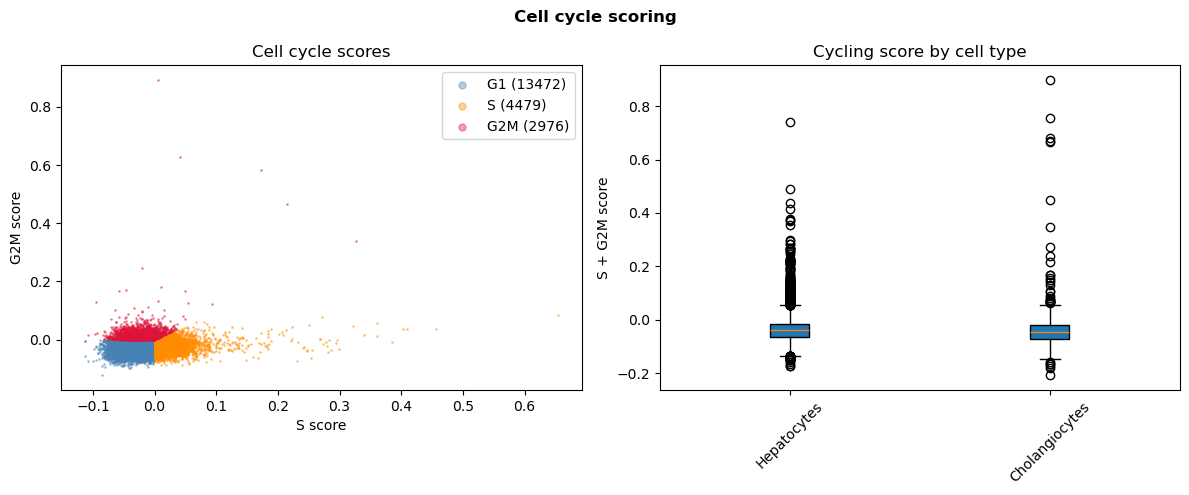


Cycling cells (S or G2M): 35.6%
Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  >10% cycling cells detected.
   Consider regressing out cell cycle before PCA:
   sc.pp.regress_out(adata, ['S_score', 'G2M_score'])
   Uncomment the line below if needed.


In [6]:
# Standard Seurat/Scanpy cell cycle gene lists (human, from Tirosh et al. 2015)
# These are loaded from scanpy's built-in list
S_GENES_URL = "https://raw.githubusercontent.com/scverse/scanpy/main/src/scanpy/datasets/pbmc3k_filtered_gene_bc_matrices/gene_lists/s_genes_tirosh.txt"
G2M_GENES_URL = "https://raw.githubusercontent.com/scverse/scanpy/main/src/scanpy/datasets/pbmc3k_filtered_gene_bc_matrices/gene_lists/g2m_genes_tirosh.txt"

# Built-in fallback lists (Tirosh et al. 2015, commonly used)
S_GENES = [
    "MCM5", "PCNA", "TYMS", "FEN1", "MCM2", "MCM4", "RRM1", "UNG", "GINS2",
    "MCM6", "CDCA7", "DTL", "PRIM1", "UHRF1", "MLF1IP", "HELLS", "RFC2",
    "RPA2", "NASP", "RAD51AP1", "GMNN", "WDR76", "SLBP", "CCNE2", "UBR7",
    "POLD3", "MSH2", "ATAD2", "RAD51", "RRM2", "CDC45", "CDC6", "EXO1",
    "TIPIN", "DSCC1", "BLM", "CASP8AP2", "USP1", "CLSPN", "POLA1", "CHAF1B",
    "BRIP1", "E2F8",
]
G2M_GENES = [
    "HMGB2", "CDK1", "NUSAP1", "UBE2C", "BIRC5", "TPX2", "TOP2A", "NDC80",
    "CKS2", "NUF2", "CKS1B", "MKI67", "TMPO", "CENPF", "TACC3", "FAM64A",
    "SMC4", "CCNB2", "CKAP2L", "CKAP2", "AURKB", "BUB1", "KIF11", "ANP32E",
    "TUBB4B", "GTSE1", "KIF20B", "HJURP", "CDCA3", "HN1", "CDC20", "TTK",
    "CDC25C", "KIF2C", "RANGAP1", "NCAPD2", "DLGAP5", "CDCA2", "CDCA8",
    "ECT2", "KIF23", "HMMR", "AURKA", "PSRC1", "ANLN", "LBR", "CKAP5",
    "CENPE", "CTCF", "NEK2", "G2E3", "GAS2L3", "CBX5", "CENPA",
]

# Filter to genes actually present in the dataset
s_genes_present   = [g for g in S_GENES   if g in adata.var_names]
g2m_genes_present = [g for g in G2M_GENES if g in adata.var_names]

print(f"S genes found   : {len(s_genes_present)} / {len(S_GENES)}")
print(f"G2M genes found : {len(g2m_genes_present)} / {len(G2M_GENES)}")

if len(s_genes_present) >= 5 and len(g2m_genes_present) >= 5:
    sc.tl.score_genes_cell_cycle(
        adata,
        s_genes=s_genes_present,
        g2m_genes=g2m_genes_present,
    )

    phase_counts = adata.obs["phase"].value_counts()
    print("\nCell cycle phase distribution:")
    for phase, n in phase_counts.items():
        print(f"  {phase:4s}: {n:6d} ({100*n/adata.n_obs:.1f}%)")

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Plot S-score vs G2M-score, coloured by phase Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    phase_colors = {"G1": "steelblue", "S": "darkorange", "G2M": "crimson"}
    for phase in ["G1", "S", "G2M"]:
        mask = adata.obs["phase"] == phase
        axes[0].scatter(
            adata.obs.loc[mask, "S_score"],
            adata.obs.loc[mask, "G2M_score"],
            s=1, alpha=0.4, label=f"{phase} ({mask.sum()})",
            color=phase_colors[phase], rasterized=True,
        )
    axes[0].set_xlabel("S score")
    axes[0].set_ylabel("G2M score")
    axes[0].set_title("Cell cycle scores")
    axes[0].legend(markerscale=5)

    # S+G2M score by cell type Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ are cycling cells enriched in one population?
    adata.obs["cycling_score"] = adata.obs["S_score"] + adata.obs["G2M_score"]
    if "cell.annotation" in adata.obs.columns:
        cell_types = adata.obs["cell.annotation"].unique()
        axes[1].boxplot(
            [adata.obs.loc[adata.obs["cell.annotation"] == ct, "cycling_score"].values
             for ct in cell_types],
            labels=cell_types,
            patch_artist=True,
        )
        axes[1].set_ylabel("S + G2M score")
        axes[1].set_title("Cycling score by cell type")
        axes[1].tick_params(axis="x", rotation=45)

    plt.suptitle("Cell cycle scoring", fontsize=12, weight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "cell_cycle_scores.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Decision: regress out cell cycle? Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    cycling_pct = (adata.obs["phase"] != "G1").mean() * 100
    print(f"\nCycling cells (S or G2M): {cycling_pct:.1f}%")
    if cycling_pct > 10:
        print("Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  >10% cycling cells detected.")
        print("   Consider regressing out cell cycle before PCA:")
        print("   sc.pp.regress_out(adata, ['S_score', 'G2M_score'])")
        print("   Uncomment the line below if needed.")
        sc.pp.regress_out(adata, ["S_score", "G2M_score"])  # <-- uncomment if needed
    else:
        print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Low cycling fraction Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ cell cycle regression not required.")
else:
    print("Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  Too few cell cycle genes present Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ scoring skipped.")
    print("   This may be expected if MT genes and pseudogenes were removed.")

In [7]:
# ── Verifică mai întâi ce markeri de zonare sunt în dataset ──────────────────
pericentral_markers = ["GLUL", "CYP2E1", "CYP1A2", "CYP3A4", "AXIN2", "LGR5"]
periportal_markers  = ["CPS1", "ASS1", "HAL", "PCK1", "SDS", "ALDOB"]

print("── Markeri pericentrați prezenți în dataset ──")
for g in pericentral_markers:
    present = g in adata.var_names
    if present:
        expr = adata[:, g].X
        if sp.issparse(expr):
            expr = expr.toarray()
        pct_expr = (expr > 0).mean() * 100
        print(f"  {g}: prezent, exprimat în {pct_expr:.1f}% din celule")
    else:
        print(f"  {g}: ABSENT din dataset")

print("\n── Markeri periportali prezenți în dataset ──")
for g in periportal_markers:
    present = g in adata.var_names
    if present:
        expr = adata[:, g].X
        if sp.issparse(expr):
            expr = expr.toarray()
        pct_expr = (expr > 0).mean() * 100
        print(f"  {g}: prezent, exprimat în {pct_expr:.1f}% din celule")
    else:
        print(f"  {g}: ABSENT din dataset")

── Markeri pericentrați prezenți în dataset ──
  GLUL: prezent, exprimat în 24.6% din celule
  CYP2E1: prezent, exprimat în 37.3% din celule
  CYP1A2: prezent, exprimat în 2.5% din celule
  CYP3A4: prezent, exprimat în 36.5% din celule
  AXIN2: prezent, exprimat în 1.1% din celule
  LGR5: prezent, exprimat în 1.3% din celule

── Markeri periportali prezenți în dataset ──
  CPS1: prezent, exprimat în 52.5% din celule
  ASS1: prezent, exprimat în 40.7% din celule
  HAL: prezent, exprimat în 42.8% din celule
  PCK1: prezent, exprimat în 48.5% din celule
  SDS: prezent, exprimat în 40.0% din celule
  ALDOB: prezent, exprimat în 55.5% din celule


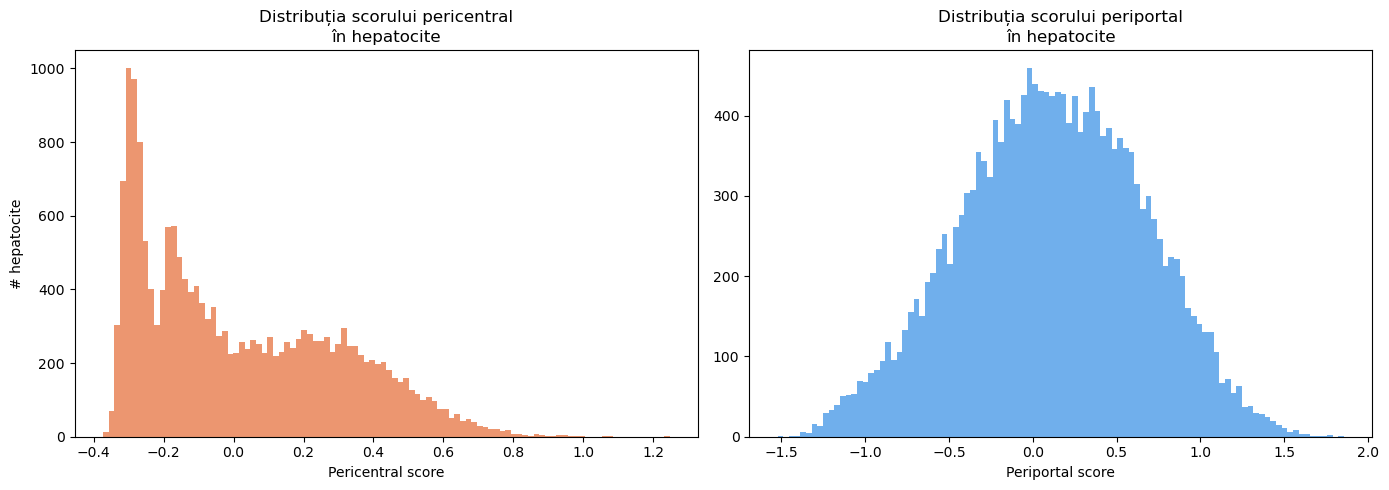


── Distribuție zone ──
zone
periportal       9489
pericentral      4982
unknown          4078
cholangiocyte    2378
Name: count, dtype: int64


In [8]:
# ── Scoring de zonare ─────────────────────────────────────────────────────────
pericentral_present = [g for g in pericentral_markers if g in adata.var_names]
periportal_present  = [g for g in periportal_markers  if g in adata.var_names]

if len(pericentral_present) >= 2:
    sc.tl.score_genes(adata, pericentral_present,
                      score_name="pericentral_score", random_state=42)
if len(periportal_present) >= 2:
    sc.tl.score_genes(adata, periportal_present,
                      score_name="periportal_score", random_state=42)

# Vizualizare pe hepatocite
hepato_mask = adata.obs["cell.annotation"] == "Hepatocytes"
adata_hep   = adata[hepato_mask].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "pericentral_score" in adata_hep.obs.columns:
    axes[0].hist(adata_hep.obs["pericentral_score"], bins=100,
                 color="#E87C4C", alpha=0.8, edgecolor="none")
    axes[0].set_xlabel("Pericentral score")
    axes[0].set_ylabel("# hepatocite")
    axes[0].set_title("Distribuția scorului pericentral\nîn hepatocite")

if "periportal_score" in adata_hep.obs.columns:
    axes[1].hist(adata_hep.obs["periportal_score"], bins=100,
                 color="#4C9BE8", alpha=0.8, edgecolor="none")
    axes[1].set_xlabel("Periportal score")
    axes[1].set_title("Distribuția scorului periportal\nîn hepatocite")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "zonation_scores.png"),
            dpi=150, bbox_inches="tight")
plt.show()

# ── Identifică hepatocitele pericentrale ─────────────────────────────────────
if "pericentral_score" in adata.obs.columns and "periportal_score" in adata.obs.columns:
    # O hepatocită e pericentrală dacă scorul pericentral > periportal
    # și scorul pericentral e deasupra medianei
    hep_mask = adata.obs["cell.annotation"] == "Hepatocytes"
    median_pc = adata.obs.loc[hep_mask, "pericentral_score"].median()

    adata.obs["zone"] = "unknown"
    adata.obs.loc[hep_mask & 
                  (adata.obs["pericentral_score"] > adata.obs["periportal_score"]) &
                  (adata.obs["pericentral_score"] > median_pc), "zone"] = "pericentral"
    adata.obs.loc[hep_mask & 
                  (adata.obs["periportal_score"] >= adata.obs["pericentral_score"]) &
                  (adata.obs["periportal_score"] > median_pc), "zone"] = "periportal"
    adata.obs.loc[adata.obs["cell.annotation"] == "Cholangiocytes", "zone"] = "cholangiocyte"

    print("\n── Distribuție zone ──")
    print(adata.obs["zone"].value_counts())

---
## Cell 3 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Highly-variable genes

In [9]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=N_TOP_HVGS,
    subset=False,
    flavor="seurat_v3",
    layer="counts",
)
print(f"Selected {adata.var['highly_variable'].sum()} highly variable genes (out of {adata.n_vars}).")

Selected 1500 highly variable genes (out of 15814).


---
## Cell 4 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Regulators (TFs) and literature lineage TFs

In [10]:
HEPATO_TFs    = {"HNF4A", "HNF1A", "FOXA2", "CEBPA", "NR5A2", "NR1H4"}
CHOLANGIO_TFs = {"SOX9", "HNF1B", "FOXA1", "GATA4", "GATA6", "SP1"}
LINEAGE_TFS   = HEPATO_TFs | CHOLANGIO_TFs

if os.path.exists(TF_LIST_PATH):
    with open(TF_LIST_PATH, 'r') as f:
        tf_list = {line.strip() for line in f if line.strip()}
else:
    print("Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦ TF list not found. Falling back to literature lineage TFs only.")
    tf_list = set()

adata.var["is_reg"]    = adata.var_names.isin(tf_list) | adata.var_names.isin(LINEAGE_TFS)
adata.var["is_target"] = adata.var["highly_variable"] & (~adata.var["is_reg"])

print(f"Regulators : {adata.var['is_reg'].sum()}")
print(f"Targets    : {adata.var['is_target'].sum()}")

# Verify all lineage TFs are present in the dataset
missing_tfs = LINEAGE_TFS - set(adata.var_names)
if missing_tfs:
    print(f"Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  Missing lineage TFs (not in dataset): {missing_tfs}")
else:
    print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ All literature lineage TFs present in dataset.")

Regulators : 1481
Targets    : 1389
Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ All literature lineage TFs present in dataset.


---
## Cell 4b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· DEG-based target refinement (HVG Ă„â€šĂ‹ÂÄ‚â€šĂ‚ÂÄ‚â€šĂ‚Â© DEG)

**logFC threshold tightened to 1.0** (= >2-fold difference), matching the published
method which requires >2-fold expression difference between cell types.
Previous version used 0.25, which is very lenient (~19% fold change).

In [11]:
DEG_TOP_N     = 300    # top N genes per group returned by rank_genes_groups
DEG_LOGFC_MIN = 1.0    # primary threshold (log2 of expm1 ratio; valid for log1p-normalised data)
DEG_PADJ_MAX  = 0.05   # Bonferroni-adjusted p-value

# -- 1. Subset to trajectory endpoints --------------------------------------
traj_cell_types = ["Hepatocytes", "Cholangiocytes"]
traj_mask = adata.obs["cell.annotation"].isin(traj_cell_types)
adata_traj = adata[traj_mask].copy()

for ct in traj_cell_types:
    n = (adata.obs["cell.annotation"] == ct).sum()
    print(f"  {ct}: {n} cells")
print(f"Trajectory subset: {traj_mask.sum()} cells")

# Clip sub-zero float artefacts that produce NaN in log2(expm1(...))
if sp.issparse(adata_traj.X):
    adata_traj.X.data = np.clip(adata_traj.X.data, 0, None)
else:
    adata_traj.X = np.clip(np.array(adata_traj.X, dtype=np.float32), 0, None)

# -- 2. Wilcoxon DEG --------------------------------------------------------
sc.tl.rank_genes_groups(
    adata_traj,
    groupby="cell.annotation",
    groups=traj_cell_types,
    reference="rest",
    method="wilcoxon",
    n_genes=DEG_TOP_N,
    use_raw=False,
)

# -- 3. Apply filters with automatic fallback --------------------------------
def _filter_degs(df, logfc_min, padj_max):
    return df[
        df["logfoldchanges"].notna() &
        (df["logfoldchanges"].abs() >= logfc_min) &
        (df["pvals_adj"] <= padj_max)
    ]

deg_genes = set()
for group in traj_cell_types:
    df = sc.get.rank_genes_groups_df(adata_traj, group=group)

    # Primary: logFC threshold matching published method
    df_filtered = _filter_degs(df, DEG_LOGFC_MIN, DEG_PADJ_MAX)

    if len(df_filtered) == 0:
        # Fallback 1: some Scanpy builds report logFC as difference in log-space (not log2 of expm1 ratio),
        # compressing the scale; 0.25 is the Seurat default for log-normalised data.
        df_filtered = _filter_degs(df, 0.25, DEG_PADJ_MAX)
        if len(df_filtered) > 0:
            print(f"  {group}: logFC>=1.0 gave 0 genes -- using logFC>=0.25 fallback")

    if len(df_filtered) == 0:
        # Fallback 2: logFC is unreliable (e.g. NaN for sparse genes); filter by Wilcoxon score + padj only
        df_filtered = df[(df["scores"] > 0) & (df["pvals_adj"] <= DEG_PADJ_MAX)]
        if len(df_filtered) > 0:
            print(f"  {group}: logFC filter failed -- using score>0 + padj fallback")

    print(f"  {group}: {len(df_filtered)} DEGs")
    deg_genes.update(df_filtered["names"].tolist())

print(f"Total unique DEGs (union): {len(deg_genes)}")

# -- 4. Intersect HVG n DEG, remove regulators -----------------------------
hvg_set  = set(adata.var_names[adata.var["highly_variable"]])
reg_set  = set(adata.var_names[adata.var["is_reg"]])
traj_targets = (deg_genes & hvg_set) - reg_set

if len(traj_targets) < 100:
    print(f"Warning: only {len(traj_targets)} in HVG n DEG -- relaxing to DEG-only filter")
    traj_targets = deg_genes - reg_set

n_before = int(adata.var["is_target"].sum())
adata.var["is_target"] = adata.var_names.isin(traj_targets)
n_after  = int(adata.var["is_target"].sum())

est_min = round(n_after * 175 / max(n_before, 1))
print(f"Target genes: {n_before} -> {n_after}  ({n_before - n_after} removed)")
print(f"Training time estimate: ~{est_min} min")

  Hepatocytes: 18549 cells
  Cholangiocytes: 2378 cells
Trajectory subset: 20927 cells
  Hepatocytes: 300 DEGs
  Cholangiocytes: 297 DEGs
Total unique DEGs (union): 597
Target genes: 1389 -> 296  (1093 removed)
Training time estimate: ~37 min


---
## Cell 5 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Build the final gene universe

In [12]:
important_mask  = adata.var["is_reg"] | adata.var["is_target"]
background_mask = ~important_mask

important_genes  = adata.var_names[important_mask]
background_genes = adata.var_names[background_mask]

print(f"Important genes (regulators + targets), kept in full : {len(important_genes)}")
print(f"Background (non-important) genes available           : {len(background_genes)}")

rng = np.random.default_rng(42)
if N_BACKGROUND_GENES is None or len(background_genes) <= N_BACKGROUND_GENES:
    background_sample = background_genes.to_numpy()
elif N_BACKGROUND_GENES == 0:
    background_sample = np.array([], dtype=object)
else:
    background_sample = rng.choice(background_genes.to_numpy(), size=N_BACKGROUND_GENES, replace=False)

keep_genes = pd.Index(important_genes).union(pd.Index(background_sample))
adata = adata[:, keep_genes].copy()

print(f"Final matrix : {adata.n_obs} cells Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ {adata.n_vars} genes")
print(f"  Regulators : {adata.var['is_reg'].sum()}")
print(f"  Targets    : {adata.var['is_target'].sum()}")
print(f"  Background : {(~(adata.var['is_reg'] | adata.var['is_target'])).sum()}")

Important genes (regulators + targets), kept in full : 1777
Background (non-important) genes available           : 14037
Final matrix : 20927 cells Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ 2277 genes
  Regulators : 1481
  Targets    : 296
  Background : 500


---
## Cell 6 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Graph + DPT pseudotime on the full cell set

In [13]:
import scipy.sparse as sp

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Guard: validate adata.X before PCA Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
_x_ok = (sp.issparse(adata.X) or
         (isinstance(adata.X, np.ndarray) and adata.X.ndim == 2))
if not _x_ok:
    print(f"Warning: adata.X is {type(adata.X)} Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ rebuilding from counts layer")
    counts_raw = adata.layers["counts"]
    if sp.issparse(counts_raw):
        counts_raw = counts_raw.toarray()
    adata.X = counts_raw.astype(np.float32)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    print("Rebuilt adata.X from counts (normalize_total + log1p).")
else:
    if sp.issparse(adata.X):
        adata.X.data = np.nan_to_num(adata.X.data, nan=0.0, posinf=0.0, neginf=0.0)
    else:
        adata.X = np.nan_to_num(adata.X.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)

_hvg_col = "highly_variable"
_use_hvg = _hvg_col in adata.var.columns and adata.var[_hvg_col].sum() > 0
if not _use_hvg:
    print("Warning: no highly_variable flag found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ PCA will use all genes.")

sc.pp.pca(adata, n_comps=20,
          mask_var=_hvg_col if _use_hvg else None,
          svd_solver="auto")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
sc.tl.diffmap(adata, n_comps=10)

hepato_mask = adata.obs["cell.annotation"] == "Hepatocytes"
hepato_idx  = np.where(hepato_mask)[0]

if len(hepato_idx) > 0:
    dc1_vals = adata.obsm["X_diffmap"][hepato_idx, 0]
    adata.uns["iroot"] = int(hepato_idx[np.argmin(dc1_vals)])
    sc.tl.dpt(adata, n_dcs=10)
    print("DPT pseudotime computed successfully on the full cell set.")
else:
    print("Warning: No Hepatocytes found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ set adata.uns['iroot'] manually before running.")

print(f"dpt_pseudotime range: {adata.obs['dpt_pseudotime'].min():.3f} Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş {adata.obs['dpt_pseudotime'].max():.3f}")

DPT pseudotime computed successfully on the full cell set.
dpt_pseudotime range: 0.000 Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş 1.000


In [14]:
# VerificÄ cÄ pseudotimul nu e dominat de cycling
corr_s = np.corrcoef(
    adata.obs["dpt_pseudotime"],
    adata.obs["S_score"]
)[0, 1]
corr_g2m = np.corrcoef(
    adata.obs["dpt_pseudotime"],
    adata.obs["G2M_score"]
)[0, 1]
print(f"CorelaČ›ie pseudotime ~ S_score  : {corr_s:.3f}")
print(f"CorelaČ›ie pseudotime ~ G2M_score: {corr_g2m:.3f}")
print("(Ideal: ambele aproape de 0 dupÄ regress_out)")

CorelaČ›ie pseudotime ~ S_score  : -0.075
CorelaČ›ie pseudotime ~ G2M_score: -0.002
(Ideal: ambele aproape de 0 dupÄ regress_out)


---
## Cell 7 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Serialize for Velorama

In [15]:
# ── Cell 7 · Serialize for Velorama ─────────────────────────────────────────
# FIX: salvăm is_reg / is_target / background în adata.uns
# astfel Cell 9 le poate recupera exact, fără să le re-derive greșit.

# ── 0. Verifică că subsetul de gene din Cell 5 a fost aplicat corect ─────────
if adata.n_vars > 3000:
    print(f"⚠️  adata are {adata.n_vars} gene — Cell 5 nu a rulat corect pe acest adata.")
    print("   Re-aplică subsetul acum...")
    _important_mask  = adata.var["is_reg"] | adata.var["is_target"]
    _background_mask = ~_important_mask
    _background_genes = adata.var_names[_background_mask]
    _rng = np.random.default_rng(42)
    _bg_sample = _rng.choice(
        _background_genes.to_numpy(),
        size=min(N_BACKGROUND_GENES, len(_background_genes)),
        replace=False
    )
    _keep = pd.Index(adata.var_names[_important_mask]).union(pd.Index(_bg_sample))
    adata = adata[:, _keep].copy()
    print(f"   ✅ Subset aplicat: {adata.n_vars} gene")
else:
    print(f"✅ adata are {adata.n_vars} gene — subset din Cell 5 OK")

# ── 1. Salvează listele exacte în uns ────────────────────────────────────────
# Aceasta este cheia fix-ului: Cell 9 va citi din uns, nu va re-deriva.
adata.uns["velorama_reg_names"]    = list(adata.var_names[adata.var["is_reg"]])
adata.uns["velorama_target_names"] = list(adata.var_names[adata.var["is_target"]])
adata.uns["velorama_bg_names"]     = list(
    adata.var_names[~(adata.var["is_reg"] | adata.var["is_target"])]
)

print(f"Salvat în uns:")
print(f"  regulatori : {len(adata.uns['velorama_reg_names'])}")
print(f"  targets    : {len(adata.uns['velorama_target_names'])}")
print(f"  background : {len(adata.uns['velorama_bg_names'])}")

# Verificare: suma trebuie să fie egală cu n_vars
_total = (len(adata.uns["velorama_reg_names"]) +
          len(adata.uns["velorama_target_names"]) +
          len(adata.uns["velorama_bg_names"]))
assert _total == adata.n_vars, (
    f"⛔ Sumă greșită: {_total} != {adata.n_vars} — verifică Cell 5!"
)
print(f"  total check: {_total} == {adata.n_vars} ✅")

# ── 2. Convertește la float32 și salvează ────────────────────────────────────
adata.X = adata.X.astype(np.float32)
for layer in adata.layers:
    adata.layers[layer] = adata.layers[layer].astype(np.float32)

save_path = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")
adata.write_h5ad(save_path)
print(f"\n✅ Saved to → {save_path}")
print(f"   Gene salvate  : {adata.n_vars}")
print(f"   Celule salvate: {adata.n_obs}")
print(f"   RAM estimate (dense): {adata.n_obs * adata.n_vars * 4 / 1e9:.3f} GiB")


✅ adata are 2277 gene — subset din Cell 5 OK
Salvat în uns:
  regulatori : 1481
  targets    : 296
  background : 500
  total check: 2277 == 2277 ✅



✅ Saved to → C:\Users\Floarea\Desktop\corebioinfo\codes\velorama\velorama_output\liver_endstage.h5ad
   Gene salvate  : 2277
   Celule salvate: 20927
   RAM estimate (dense): 0.191 GiB


---
## Cell 9 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Reload the prepared data, get regulator/target indices

In [16]:
import anndata as ad

h5ad_path = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad")
adata_sub  = ad.read_h5ad(h5ad_path)

print(f"Loaded: {adata_sub.n_obs} cells x {adata_sub.n_vars} genes")

# ── Recuperează is_reg și is_target ─────────────────────────────────────────
# Prioritate 1: din uns (salvat de Cell 7 — metoda corectă)
# Prioritate 2: din coloanele var (dacă există deja corecte)
# Prioritate 3: raise error — cere re-rulare Cell 5 → 7

if "velorama_reg_names" in adata_sub.uns and "velorama_target_names" in adata_sub.uns:
    # ── Metoda corectă: recuperare exactă din uns ────────────────────────────
    reg_names_stored    = adata_sub.uns["velorama_reg_names"]
    target_names_stored = adata_sub.uns["velorama_target_names"]

    adata_sub.var["is_reg"]    = adata_sub.var_names.isin(reg_names_stored)
    adata_sub.var["is_target"] = adata_sub.var_names.isin(target_names_stored)

    print(f"✅ is_reg și is_target recuperate din adata.uns (metoda corectă)")

elif "is_reg" in adata_sub.var.columns and "is_target" in adata_sub.var.columns:
    # ── Coloanele există în var — verifică că targets sunt puțini (DEG filtrate) ──
    n_t = adata_sub.var["is_target"].sum()
    if n_t > 2000:
        raise ValueError(
            f"⛔ is_target are {n_t} gene — probabil fallback greșit fără filtrul DEG.\n"
            f"   Re-rulează Cell 4b → Cell 5 → Cell 7 pentru a salva uns metadata."
        )
    print(f"✅ is_reg și is_target prezente în var (verificate: {n_t} targets)")

else:
    raise ValueError(
        "⛔ Coloanele is_reg / is_target lipsesc și adata.uns nu conține backup.\n"
        "   Soluție: re-rulează în ordine Cell 4 → Cell 4b → Cell 5 → Cell 6 → Cell 7\n"
        "   Cell 7 (versiunea nouă) salvează automat listele în adata.uns."
    )

# ── Verificări finale ────────────────────────────────────────────────────────
n_reg    = int(adata_sub.var["is_reg"].sum())
n_target = int(adata_sub.var["is_target"].sum())
n_bg     = int((~(adata_sub.var["is_reg"] | adata_sub.var["is_target"])).sum())
overlap  = int((adata_sub.var["is_reg"] & adata_sub.var["is_target"]).sum())

print(f"\nRegulatoti  : {n_reg}")
print(f"Targets     : {n_target}")
print(f"Background  : {n_bg}")
print(f"Total gene  : {adata_sub.n_vars}  (check: {n_reg + n_target + n_bg})")
print(f"Overlap reg∩target (trebuie 0): {overlap}")

if overlap > 0:
    print("⚠️  Există overlap între regulatori și targets — verifică Cell 4 și 4b!")

print(f"\ndpt_pseudotime present: {'dpt_pseudotime' in adata_sub.obs.columns}")
print(f"X_pca present         : {'X_pca' in adata_sub.obsm}")

if "dpt_pseudotime" not in adata_sub.obs.columns:
    print("⚠️  dpt_pseudotime lipsește — re-rulează Cell 6!")
if "X_pca" not in adata_sub.obsm:
    print("⚠️  X_pca lipsește — re-rulează Cell 6!")

# ── Indici pentru training ────────────────────────────────────────────────────
reg_idx    = np.where(adata_sub.var["is_reg"].values)[0]
target_idx = np.where(adata_sub.var["is_target"].values)[0]
reg_names    = adata_sub.var_names[adata_sub.var["is_reg"].values]
target_names = adata_sub.var_names[adata_sub.var["is_target"].values]

print(f"\nRegs: {len(reg_idx)}, Targets: {len(target_idx)}")
print(f"Primele 5 targets: {list(target_names[:5])}")


Loaded: 20927 cells x 2277 genes
✅ is_reg și is_target recuperate din adata.uns (metoda corectă)

Regulatoti  : 1481
Targets     : 296
Background  : 500
Total gene  : 2277  (check: 2277)
Overlap reg∩target (trebuie 0): 0

dpt_pseudotime present: True
X_pca present         : True

Regs: 1481, Targets: 296
Primele 5 targets: ['A2M', 'ABCB4', 'ABCC1', 'ABCC4', 'ABTB2']


---
## Cell 10 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Scale, build tensors, construct the DAG and diffusion lags

In [ ]:
import torch
from velorama.utils import construct_dag, calculate_diffusion_lags

print("Scaling expression matrix...")
sc.pp.scale(adata_sub)

X_dense = adata_sub.X.toarray() if sp.issparse(adata_sub.X) else np.array(adata_sub.X)
if np.isnan(X_dense).any():
    print("Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦ NaNs from zero-variance genes Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ cleaning...")
    X_dense = np.nan_to_num(X_dense, nan=0.0)
    adata_sub.X = sp.csr_matrix(X_dense) if sp.issparse(adata_sub.X) else X_dense

X_np = np.ascontiguousarray(X_dense, dtype=np.float32)
X    = torch.tensor(X_np)
print(f"X shape: {X.shape}")

print("Constructing DAG (this uses the full-cell X_pca + iroot from Cell 6)...")
A = construct_dag(adata_sub, dynamics="pseudotime", ptloc=None, proba=False)
print(f"DAG shape: {A.shape}")

print(f"Calculating diffusion lags (lag={LAG})...")
AX = calculate_diffusion_lags(A, X, LAG)

if isinstance(AX, (list, tuple)):
    print(f"AX: list of {len(AX)} tensors, each shape {AX[0].shape}")
else:
    print(f"AX shape: {AX.shape}")
    if AX.dim() == 2:
        AX = [AX] * LAG
        print(f"  Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË wrapped into list of {len(AX)} tensors for train_model")

print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Velorama inputs ready.")

c:\Users\Floarea\miniconda3\envs\velorama\lib\site-packages\ray\_private\parameter.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Scaling expression matrix...
X shape: torch.Size([20927, 2277])
Constructing DAG (this uses the full-cell X_pca + iroot from Cell 6)...
DAG shape: torch.Size([20927, 20927])
Calculating diffusion lags (lag=2)...


In [ ]:
# â”€â”€ Cell 10b Â· Lag sensitivity â€” alege LAG optim ĂŽNAINTE de training â”€â”€â”€â”€â”€â”€â”€â”€â”€
# RuleazÄ DUPÄ‚ Cell 10 (ai deja A, X_np, X, target_idx disponibile)
# AntreneazÄ pe un subset mic de gene Č›intÄ la LAG=1,2,3
# Č™i alege lag-ul care recupereazÄ cel mai bine biologia cunoscutÄ.

import time
from tqdm.auto import tqdm
from velorama import train_model
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

LAGS_TO_TEST        = [1, 2, 3]
N_SENSITIVITY_GENES = 50   # subset fix â€” suficient pentru comparaČ›ie, ~5-8 min per lag
SENSITIVITY_SEED    = 77
LAG_SENS_DIR        = os.path.join(OUTPUT_DIR, "lag_sensitivity")
os.makedirs(LAG_SENS_DIR, exist_ok=True)

# AcelaČ™i subset de gene Č›intÄ pentru toate lag-urile â€” comparaČ›ie corectÄ
rng_sens = np.random.default_rng(SENSITIVITY_SEED)
sens_idx = rng_sens.choice(
    target_idx,
    size=min(N_SENSITIVITY_GENES, len(target_idx)),
    replace=False
)
print(f"Subset sensitivity: {len(sens_idx)} gene Č›intÄ")
print(f"Lags de testat: {LAGS_TO_TEST}")
print(f"Timp estimat: ~{len(sens_idx) * 0.3 * len(LAGS_TO_TEST):.0f} min total\n")

# â”€â”€ 1. Training pe subset la fiecare lag â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
lag_grn = {}   # lag_val â†’ DataFrame (reg_names Ă— sens_target_names)

for lag_val in LAGS_TO_TEST:
    print(f"{'â”€'*45}")
    print(f"  Testez LAG = {lag_val}")
    print(f"{'â”€'*45}")

    lag_dir_name = f"sensitivity_lag{lag_val}"
    lag_dir_full = os.path.join(LAG_SENS_DIR,

---
## Cell 11 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Sequential Velorama training across target genes

In [ ]:
import torch
import numpy as np
import scipy.sparse as sp
from joblib import Parallel, delayed
from velorama import train_model
import time

os.makedirs(os.path.join(OUTPUT_DIR, DATASET_NAME), exist_ok=True)

TRAIN_CONFIG_BASE = dict(
    reg_target  = False,
    seed        = 42,
    lr          = 0.01,
    lam         = 0.01,
    lam_ridge   = 1e-4,
    penalty     = "H",
    lag         = LAG,
    hidden      = [16],
    max_iter    = 150,      # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Äąâ€ş from 200; early stopping handles the rest
    device      = "cpu",
    lookback    = 5,
    check_every = 10,       # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă‚Â from 25; checks 2.5x more often Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË earlier exit
    verbose     = False,
    dynamics    = "pseudotime",
    results_dir = OUTPUT_DIR,
    dir_name    = DATASET_NAME,
)

def _train_gene(t_idx, gene_name, X_np_arr, AX_np_arr, config):
    """Train one target gene model inside a loky worker process."""
    import torch
    from velorama import train_model
    torch.set_num_threads(1)   # prevent thread pile-up across parallel workers
    AX_t = torch.tensor(AX_np_arr, dtype=torch.float32)
    Y_t  = torch.tensor(X_np_arr[:, [t_idx]], dtype=torch.float32)
    train_model({"AX": AX_t, "AY": AX_t, "Y": Y_t, "name": gene_name, **config})
    return gene_name

# Convert AX to a numpy array Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ loky memory-maps numpy arrays, cannot pickle torch tensors
if isinstance(AX, torch.Tensor):
    _AX_np = AX.numpy()
elif sp.issparse(AX):
    _AX_np = AX.toarray().astype(np.float32)
else:
    _AX_np = np.asarray(AX, dtype=np.float32)

N_WORKERS = max(1, min(3, N_CPUS, len(target_idx)))   # leave 1 core for OS / notebook UI
print(f"Training {len(target_idx)} target genes Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· {N_WORKERS} parallel workers")
print(f"  max_iter=150 (was 200) Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· check_every=10 (was 25)")
print(f"  Already-finished .pt files are skipped automatically.")
start_full = time.time()

Parallel(n_jobs=N_WORKERS, backend="loky", verbose=5)(
    delayed(_train_gene)(
        int(t_idx),
        str(adata_sub.var_names[t_idx]),
        X_np,
        _AX_np,
        TRAIN_CONFIG_BASE,
    )
    for t_idx in target_idx
)

elapsed_full = time.time() - start_full
print(f"\nĂ„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Done Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ {len(target_idx)} models in {elapsed_full/60:.1f} min")


---
## Cell 12 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Load saved `.pt` files (parallel I/O)

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

pt_dir = os.path.join(OUTPUT_DIR, DATASET_NAME)

def pt_filename(gene_name, ignore_lag=False):
    stem = f"{gene_name}.seed42.lam0.01.h16.H.lag{LAG}.pseudotime"
    return os.path.join(pt_dir, stem + (".ignore_lag.pt" if ignore_lag else ".pt"))

def _load_one(t_idx):
    gene_name = adata_sub.var_names[t_idx]
    p1 = pt_filename(gene_name, ignore_lag=False)
    p2 = pt_filename(gene_name, ignore_lag=True)
    if not os.path.exists(p1):
        return t_idx, None, None
    GC     = torch.load(p1, map_location="cpu").detach().numpy()
    GC_lag = torch.load(p2, map_location="cpu").detach().numpy()
    return t_idx, GC[0, :, :], GC_lag[0, :]

gc, gc_lag = {}, {}
print("Loading trained model outputs in parallel...")
with ThreadPoolExecutor(max_workers=min(16, N_CPUS * 2)) as pool:
    futures = [pool.submit(_load_one, t_idx) for t_idx in target_idx]
    for fut in as_completed(futures):
        t_idx, GC_mat, GC_lag_vec = fut.result()
        if GC_mat is None:
            print(f"  Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  Missing: {adata_sub.var_names[t_idx]}")
            continue
        gc[t_idx] = GC_mat
        gc_lag[t_idx] = GC_lag_vec

print(f"Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Loaded {len(gc)} / {len(target_idx)} target gene networks.")

---
## Cell 13 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Assemble the full GRN / lag matrices and export

In [ ]:
all_genes     = adata_sub.var_names
n_total_genes = len(all_genes)
print(f"Total genes in working AnnData: {n_total_genes}")

grn_full = pd.DataFrame(0.0, index=all_genes, columns=all_genes)
lag_full = pd.DataFrame(0.0, index=all_genes, columns=all_genes)

for t_idx, GC_matrix in gc.items():
    target_gene_name  = adata_sub.var_names[t_idx]
    gc_summary_vector = GC_matrix.max(axis=1)
    lag_vector        = gc_lag[t_idx]

    if len(gc_summary_vector) > n_total_genes:
        gc_summary_vector = gc_summary_vector[:n_total_genes]
        lag_vector        = lag_vector[:n_total_genes]

    n_predictors = len(gc_summary_vector)
    grn_full.iloc[:n_predictors, t_idx] = gc_summary_vector
    lag_full.iloc[:n_predictors, t_idx] = lag_vector

print(f"GRN full matrix shape: {grn_full.shape}")

reg_names    = adata_sub.var_names[adata_sub.var["is_reg"] == True]
target_names = adata_sub.var_names[adata_sub.var["is_target"] == True]

grn_df = grn_full.loc[reg_names, target_names]
lag_df = lag_full.loc[reg_names, target_names]

print(f"GRN filtered (TFs Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ targets): {grn_df.shape}")

grn_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv"))
lag_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv"))
print(f"Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Saved matrices to {OUTPUT_DIR}")

stacked_df = grn_df.stack().reset_index()
stacked_df.columns = ["TF", "target", "grn_score"]
print("\nTop 10 TFĂ„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ştarget interactions:")
print(stacked_df.sort_values("grn_score", ascending=False).head(10).to_string(index=False))

---
## Cell 13b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Permutation null Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ data-driven significance threshold

### What is a permutation null and why do we need it?

The GRN scores from Velorama are **not p-values** Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ they are Granger causal strengths
with no built-in notion of statistical significance. The mean+2Ä‚â€žÄąËťÄ‚â€šĂ‚Â threshold used in
visualisation is purely descriptive.

A **permutation null** asks: *what score would Velorama assign if there were no real
causal structure?* We answer this by destroying the temporal ordering (shuffling
pseudotime labels), re-running the DAG construction + diffusion lags on a random subset
of targets, and collecting the resulting scores. These shuffled scores define what the
model produces **by chance**.

**Any real score above the 95th or 99th percentile of the null distribution
is a statistically significant edge.**

### Why pseudotime shuffling works
The DAG encodes the direction of time. Shuffling pseudotime randomly reorders which
cells are "before" and "after" each other, breaking all real regulatory relationships
while preserving the marginal expression distributions. Scores that survive this
destruction cannot be explained by co-expression alone.

### Computational cost
Full re-training on shuffled data is expensive. We use a **fast approximation**:
- Shuffle pseudotime Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË rebuild DAG Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË recompute AX_null (the diffusion-lagged input)
- Train on N_NULL_GENES randomly chosen targets (not all targets)
- Collect the resulting scores as the null distribution

N_NULL_GENES=30 gives a good null estimate in ~15Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ş20 min.

In [ ]:
import time
from tqdm import tqdm
from velorama.utils import construct_dag, calculate_diffusion_lags
from velorama import train_model

N_NULL_GENES    = 30    # targets to train on per permutation (more = better null, slower)
N_PERMUTATIONS  = 1     # number of full shuffles (1 is enough for a threshold; 3+ for a p-value)
NULL_SEED       = 99
NULL_DIR        = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_null")
os.makedirs(NULL_DIR, exist_ok=True)

null_scores_all = []   # will hold all TFĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žËtarget scores from shuffled runs

rng_null = np.random.default_rng(NULL_SEED)

for perm_idx in range(N_PERMUTATIONS):
    print(f"\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Permutation {perm_idx + 1} / {N_PERMUTATIONS} Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
    t_perm_start = time.time()

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 1. Reload a fresh copy and shuffle pseudotime Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    adata_null = ad.read_h5ad(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}.h5ad"))

    # Shuffle pseudotime labels among all cells
    shuffled_pt = adata_null.obs["dpt_pseudotime"].values.copy()
    rng_null.shuffle(shuffled_pt)
    adata_null.obs["dpt_pseudotime"] = shuffled_pt

    # iroot becomes meaningless after shuffling Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ set to cell 0 (arbitrary)
    adata_null.uns["iroot"] = 0

    print("  Scaling null expression...")
    sc.pp.scale(adata_null)

    X_null_dense = adata_null.X.toarray() if sp.issparse(adata_null.X) else np.array(adata_null.X)
    X_null_dense = np.nan_to_num(X_null_dense.astype(np.float32), nan=0.0)
    X_null_np    = np.ascontiguousarray(X_null_dense, dtype=np.float32)
    X_null_t     = torch.tensor(X_null_np)

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 2. Build null DAG (uses shuffled pseudotime) Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    print("  Building null DAG (shuffled pseudotime)...")
    A_null  = construct_dag(adata_null, dynamics="pseudotime", ptloc=None, proba=False)
    AX_null = calculate_diffusion_lags(A_null, X_null_t, LAG)
    if not isinstance(AX_null, (list, tuple)):
        if AX_null.dim() == 2:
            AX_null = [AX_null] * LAG

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 3. Sample N_NULL_GENES target indices Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    null_target_sample = rng_null.choice(target_idx, size=min(N_NULL_GENES, len(target_idx)),
                                         replace=False)

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 4. Train on shuffled data Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    NULL_TRAIN_CONFIG = dict(
        reg_target  = False,
        seed        = NULL_SEED + perm_idx,
        lr          = 0.01,
        lam         = 0.01,
        lam_ridge   = 1e-4,
        penalty     = "H",
        lag         = LAG,
        hidden      = [16],
        max_iter    = 200,
        device      = "cpu",
        lookback    = 5,
        check_every = 25,
        verbose     = False,
        dynamics    = "pseudotime",
        results_dir = OUTPUT_DIR,
        dir_name    = f"{DATASET_NAME}_null",
    )

    print(f"  Training {len(null_target_sample)} null models...")
    null_gc = {}
    for t_idx in tqdm(null_target_sample, desc=f"  Null perm {perm_idx+1}"):
        gene_name = adata_null.var_names[t_idx]
        Y_null    = torch.tensor(X_null_np[:, [t_idx]], dtype=torch.float32)
        train_model({"AX": AX_null, "AY": AX_null, "Y": Y_null,
                     "name": f"null_p{perm_idx}_{gene_name}", **NULL_TRAIN_CONFIG})

    # Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 5. Load null model outputs Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
    for t_idx in null_target_sample:
        gene_name = adata_null.var_names[t_idx]
        p_null = os.path.join(
            OUTPUT_DIR, f"{DATASET_NAME}_null",
            f"null_p{perm_idx}_{gene_name}.seed{NULL_SEED + perm_idx}.lam0.01.h16.H.lag{LAG}.pseudotime.pt"
        )
        if os.path.exists(p_null):
            GC_null = torch.load(p_null, map_location="cpu").detach().numpy()
            # GC_null shape: (1, n_regs, n_lags) or (1, n_regs, n_genes)
            scores = GC_null[0].max(axis=1) if GC_null[0].ndim == 2 else GC_null[0]
            null_scores_all.extend(scores.tolist())

    elapsed_perm = time.time() - t_perm_start
    print(f"  Permutation {perm_idx+1} done in {elapsed_perm/60:.1f} min")
    print(f"  Null scores collected so far: {len(null_scores_all)}")

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 6. Compute null thresholds Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
null_scores_arr = np.array(null_scores_all)
NULL_P95  = np.percentile(null_scores_arr, 95)
NULL_P99  = np.percentile(null_scores_arr, 99)
NULL_P999 = np.percentile(null_scores_arr, 99.9)

print(f"\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Permutation null thresholds (n={len(null_scores_arr)} null scores) Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
print(f"  95th percentile  (FPR ~5%)   : {NULL_P95:.5f}")
print(f"  99th percentile  (FPR ~1%)   : {NULL_P99:.5f}")
print(f"  99.9th percentile (FPR ~0.1%): {NULL_P999:.5f}")

# Save null scores
null_df = pd.DataFrame({"null_grn_score": null_scores_arr})
null_df.to_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_null_scores.csv"), index=False)

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 7. Apply to real GRN Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
real_scores = grn_df.values.flatten()
n_sig_p95  = (real_scores > NULL_P95).sum()
n_sig_p99  = (real_scores > NULL_P99).sum()
n_sig_p999 = (real_scores > NULL_P999).sum()
n_total    = len(real_scores)

print(f"\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Real GRN edges above null thresholds Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
print(f"  > p95  threshold ({NULL_P95:.4f}): {n_sig_p95:,} / {n_total:,} ({100*n_sig_p95/n_total:.2f}%)")
print(f"  > p99  threshold ({NULL_P99:.4f}): {n_sig_p99:,} / {n_total:,} ({100*n_sig_p99/n_total:.2f}%)")
print(f"  > p99.9 threshold ({NULL_P999:.4f}): {n_sig_p999:,} / {n_total:,} ({100*n_sig_p999/n_total:.2f}%)")

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ 8. Visualise null vs. real distribution Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(null_scores_arr, bins=100, color="grey", alpha=0.6,
        label=f"Null distribution (n={len(null_scores_arr):,})", density=True)
ax.hist(real_scores, bins=100, color="steelblue", alpha=0.6,
        label=f"Real GRN scores (n={n_total:,})", density=True)

ax.axvline(NULL_P95,  color="orange", ls="--", lw=1.5, label=f"p95  = {NULL_P95:.4f}")
ax.axvline(NULL_P99,  color="crimson", ls="--", lw=1.5, label=f"p99  = {NULL_P99:.4f}")
ax.axvline(NULL_P999, color="darkred", ls="-",  lw=1.5, label=f"p99.9 = {NULL_P999:.4f}")

ax.set_xlabel("GRN score")
ax.set_ylabel("Density")
ax.set_title(
    "Real GRN scores vs. permutation null\n"
    "(Scores above dashed lines are statistically significant)"
)
ax.legend(fontsize=9)
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "permutation_null_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

# Store thresholds for downstream use
GRN_THRESHOLD_P95  = NULL_P95
GRN_THRESHOLD_P99  = NULL_P99
GRN_THRESHOLD_P999 = NULL_P999
print(f"\nĂ„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Use GRN_THRESHOLD_P99 = {GRN_THRESHOLD_P99:.5f} as your significance cutoff.")
print("   Filter with: results[results['grn_score'] > GRN_THRESHOLD_P99]")

---
## Cell 14 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Load results for visualisation

In [ ]:
import seaborn as sns

grn_df = pd.read_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_grn_scores.csv"), index_col=0)
lag_df = pd.read_csv(os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_lag_scores.csv"), index_col=0)
print(f"GRN: {grn_df.shape}  |  Lag: {lag_df.shape}")

# Load null thresholds if re-running from this cell
null_csv_path = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_null_scores.csv")
if os.path.exists(null_csv_path):
    null_scores_arr   = pd.read_csv(null_csv_path)["null_grn_score"].values
    GRN_THRESHOLD_P95  = np.percentile(null_scores_arr, 95)
    GRN_THRESHOLD_P99  = np.percentile(null_scores_arr, 99)
    GRN_THRESHOLD_P999 = np.percentile(null_scores_arr, 99.9)
    print(f"Null thresholds loaded: p95={GRN_THRESHOLD_P95:.5f}, p99={GRN_THRESHOLD_P99:.5f}")
else:
    print("Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦  Null scores not found Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ run Cell 13b first.")
    print("   Using mean+2Ä‚â€žÄąËťÄ‚â€šĂ‚Â as fallback threshold.")
    scores_flat = grn_df.values.flatten()
    GRN_THRESHOLD_P95  = scores_flat.mean() + scores_flat.std()
    GRN_THRESHOLD_P99  = scores_flat.mean() + 2 * scores_flat.std()
    GRN_THRESHOLD_P999 = scores_flat.mean() + 3 * scores_flat.std()

---
## Cell 15 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Ranked interactions table

In [ ]:
results = (
    grn_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "grn_score"})
)
results = results[results["TF"] != results["target"]].copy()
results = results.sort_values("grn_score", ascending=False).reset_index(drop=True)

lag_long = (
    lag_df
    .stack()
    .reset_index()
    .rename(columns={"level_0": "TF", "level_1": "target", 0: "lag_score"})
)
results = results.merge(lag_long, on=["TF", "target"], how="left")

# Tag significance using permutation null threshold
results["significant_p99"]  = results["grn_score"] > GRN_THRESHOLD_P99
results["significant_p999"] = results["grn_score"] > GRN_THRESHOLD_P999

out_csv = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_interactions_ranked.csv")
results.to_csv(out_csv, index=False)
print(f"Total TFĂ„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ştarget pairs: {len(results):,}")
print(f"Significant (p99)    : {results['significant_p99'].sum():,}")
print(f"Significant (p99.9)  : {results['significant_p999'].sum():,}")
print(f"Saved to: {out_csv}")
print(results.head(10))

---
## Cell 16 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Top TFs by total regulatory influence

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use only significant interactions for the influence ranking
results_sig = results[results["significant_p99"]].copy()
print(f"Using {len(results_sig):,} significant interactions (p99 null threshold) for TF ranking.")

top_tf_influence = (
    results_sig
    .groupby("TF")["grn_score"]
    .sum()
    .nlargest(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_tf_influence, x="TF", y="grn_score", color="steelblue", ax=ax)
ax.set_xlabel("TF regulator")
ax.set_ylabel("Sum GRN score (significant edges only)")
ax.set_title(f"Top 20 TFs by total regulatory influence\n(edges above permutation null p99 = {GRN_THRESHOLD_P99:.4f})")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_tfs_influence.png"), dpi=150)
plt.show()

---
## Cell 17 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· GRN heatmap (top TFs Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ top targets)

In [ ]:
top_tfs     = list(results_sig.groupby("TF")["grn_score"].sum().nlargest(20).index)
top_targets = list(results_sig.groupby("target")["grn_score"].sum().nlargest(30).index)

df_heatmap = results[results["TF"].isin(top_tfs) & results["target"].isin(top_targets)].copy()
df_pivot = (
    df_heatmap
    .pivot_table(index="TF", columns="target", values="grn_score", aggfunc="max")
    .reindex(index=top_tfs, columns=top_targets)
    .fillna(0)
)

plt.figure(figsize=(14, 10), dpi=150)
sns.heatmap(df_pivot, cmap="viridis", robust=True,
            cbar_kws={"label": "Granger Causal Strength"})
plt.title("Top 20 TFs Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ Top 30 Targets", fontsize=14, weight="bold", pad=15)
plt.xlabel("Target Genes", fontsize=12)
plt.ylabel("TF Regulators", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grn_heatmap_ranked.png"), bbox_inches="tight")
plt.show()

---
## Cell 17b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· GRN score diagnostics Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ understanding the signal range

In [ ]:
scores_flat = grn_df.values.flatten()
mean_s, std_s = scores_flat.mean(), scores_flat.std()
threshold_1sd = mean_s + std_s
threshold_2sd = mean_s + 2 * std_s

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(scores_flat, bins=120, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(threshold_1sd, color="orange", ls="--", lw=1.5, label=f"mean + 1Ä‚â€žÄąËťÄ‚â€šĂ‚Â = {threshold_1sd:.4f}")
ax.axvline(threshold_2sd, color="crimson", ls="--", lw=1.5, label=f"mean + 2Ä‚â€žÄąËťÄ‚â€šĂ‚Â = {threshold_2sd:.4f}")
if 'GRN_THRESHOLD_P99' in dir():
    ax.axvline(GRN_THRESHOLD_P99, color="darkgreen", ls="-", lw=2,
               label=f"Null p99 = {GRN_THRESHOLD_P99:.4f}")
ax.set_xlabel("GRN score")
ax.set_ylabel("Count")
ax.set_title("Full GRN score distribution (all TFĂ„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬Äąâ€ştarget pairs)")
ax.legend(fontsize=9)

p95 = np.percentile(scores_flat, 95)
ax2 = axes[1]
ax2.hist(scores_flat[scores_flat >= p95], bins=80, color="darkorange", alpha=0.8, edgecolor="none")
ax2.axvline(threshold_2sd, color="crimson", ls="--", lw=1.5, label=f"mean + 2Ä‚â€žÄąËťÄ‚â€šĂ‚Â = {threshold_2sd:.4f}")
if 'GRN_THRESHOLD_P99' in dir():
    ax2.axvline(GRN_THRESHOLD_P99, color="darkgreen", ls="-", lw=2,
                label=f"Null p99 = {GRN_THRESHOLD_P99:.4f}")
ax2.set_xlabel("GRN score")
ax2.set_ylabel("Count")
ax2.set_title(f"Top 5% of scores  (Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â°Ä‚â€žĂ˘â‚¬Ĺľ {p95:.4f})")
ax2.legend(fontsize=9)

plt.suptitle("GRN score distribution Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ signal vs. background", fontsize=12, weight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grn_score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

pct_above_1sd = (scores_flat > threshold_1sd).mean() * 100
pct_above_2sd = (scores_flat > threshold_2sd).mean() * 100
print(f"Score stats Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ mean: {mean_s:.4f}  std: {std_s:.4f}  max: {scores_flat.max():.4f}")
print(f"  mean + 1Ä‚â€žÄąËťÄ‚â€šĂ‚Â = {threshold_1sd:.4f}  ({pct_above_1sd:.1f}% of pairs above)")
print(f"  mean + 2Ä‚â€žÄąËťÄ‚â€šĂ‚Â = {threshold_2sd:.4f}  ({pct_above_2sd:.1f}% of pairs above)")

---
## Cell 17c Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Row-wise z-score heatmap

In [ ]:
vmin_manual = mean_s
vmax_manual = np.percentile(scores_flat, 99)

plt.figure(figsize=(14, 10), dpi=150)
sns.heatmap(df_pivot, cmap="viridis",
            vmin=vmin_manual, vmax=vmax_manual,
            cbar_kws={"label": f"GRN score  (clipped to [{vmin_manual:.4f}, {vmax_manual:.4f}])"})
plt.title(f"Top 20 TFs Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ Top 30 Targets  Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„  manual scale  [mean, 99th pct]",
          fontsize=13, weight="bold", pad=15)
plt.xlabel("Target Genes", fontsize=11)
plt.ylabel("TF Regulators", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grn_heatmap_manual_scale.png"), bbox_inches="tight")
plt.show()

# Row-wise z-score
row_mean = df_pivot.mean(axis=1)
row_std  = df_pivot.std(axis=1).replace(0, np.nan)
df_pivot_z = df_pivot.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0)

plt.figure(figsize=(14, 10), dpi=150)
sns.heatmap(df_pivot_z, cmap="RdBu_r", center=0, vmin=-2.5, vmax=2.5,
            cbar_kws={"label": "Row z-score  (per-TF normalised)"})
plt.title(
    "Top 20 TFs Ä‚â€žĂ˘â‚¬ĹˇÄ‚ËĂ˘â€šÂ¬Ă˘â‚¬ĹĄ Top 30 Targets  Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„  row-wise z-score\n"
    "(red = TF preferentially drives this target; blue = below TF average)",
    fontsize=12, weight="bold", pad=15,
)
plt.xlabel("Target Genes", fontsize=11)
plt.ylabel("TF Regulators", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grn_heatmap_zscore.png"), bbox_inches="tight")
plt.show()

print(pd.Series(grn_df.values.flatten()).describe())
print("Non-zero scores:", (grn_df.values > 0.001).sum())

---
## Cell 18 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Interaction speed vs. strength scatter

In [ ]:
tf_stats = (
    results_sig
    .groupby("TF")
    .apply(lambda g: g.nlargest(50, "grn_score"))
    .reset_index(drop=True)
    .groupby("TF")[["grn_score", "lag_score"]]
    .mean()
    .dropna()
)

threshold = tf_stats["grn_score"].quantile(0.5)
plot_tf   = tf_stats[tf_stats["grn_score"] >= threshold]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(plot_tf["lag_score"], plot_tf["grn_score"],
           s=60, alpha=0.7, color="steelblue", edgecolors="white")
for tf_name, row in plot_tf.nlargest(10, "grn_score").iterrows():
    ax.annotate(tf_name, (row["lag_score"], row["grn_score"]), fontsize=8, ha="center", va="bottom")
ax.axvline(plot_tf["lag_score"].median(), color="grey", ls="--", lw=1, label="Median lag")
ax.set_xlabel("Mean interaction lag (slow Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚â€šĂ‚Â Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË fast)")
ax.set_ylabel("Mean Granger causal score")
ax.set_title("TF interaction speed vs. regulatory strength\n(significant interactions only)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tf_speed_vs_strength.png"), dpi=150)
plt.show()

---
## Cell 19 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Hepatocyte-specific vs. Cholangiocyte-specific TFs

In [ ]:
lit_tfs = HEPATO_TFs | CHOLANGIO_TFs
lit_results = results[results["TF"].isin(lit_tfs)].copy()

# Show both all interactions and significant-only
lit_influence_all = (
    lit_results
    .groupby("TF")["grn_score"]
    .sum()
    .reset_index()
    .assign(lineage=lambda df: df["TF"].apply(
        lambda t: "Hepatocyte" if t in HEPATO_TFs else "Cholangiocyte"
    ))
    .sort_values("grn_score", ascending=False)
)

lit_influence_sig = (
    lit_results[lit_results["significant_p99"]]
    .groupby("TF")["grn_score"]
    .sum()
    .reset_index()
    .assign(lineage=lambda df: df["TF"].apply(
        lambda t: "Hepatocyte" if t in HEPATO_TFs else "Cholangiocyte"
    ))
    .sort_values("grn_score", ascending=False)
)

palette = {"Hepatocyte": "#e88035", "Cholangiocyte": "#3576b0"}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=lit_influence_all, x="TF", y="grn_score",
            hue="lineage", palette=palette, dodge=False, ax=axes[0])
axes[0].set_title("All interactions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("Sum GRN score")

sns.barplot(data=lit_influence_sig, x="TF", y="grn_score",
            hue="lineage", palette=palette, dodge=False, ax=axes[1])
axes[1].set_title(f"Significant only (null p99 > {GRN_THRESHOLD_P99:.4f})")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylabel("Sum GRN score")

plt.suptitle("Hepatocyte vs Cholangiocyte lineage TF influence", fontsize=13, weight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "lineage_TF_comparison.png"), dpi=150)
plt.show()
print(lit_influence_sig)

---
## Cell 20 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Functional enrichment analysis Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ g:Profiler

In [ ]:
from gprofiler import GProfiler

counts_mat = adata.layers["counts"]
if sp.issparse(counts_mat):
    gene_totals = np.asarray(counts_mat.sum(axis=0)).flatten()
else:
    gene_totals = np.array(counts_mat.sum(axis=0)).flatten()

background_genes_enrich = adata.var_names[gene_totals > 0].tolist()
print(f"Background (expressed genes): {len(background_genes_enrich)}")

# Use significant interactions only for enrichment gene lists
top50_targets = (
    results_sig.groupby("target")["grn_score"]
    .sum()
    .nlargest(50)
    .index.tolist()
)

hepato_present   = [t for t in HEPATO_TFs    if t in results_sig["TF"].values]
cholangio_present = [t for t in CHOLANGIO_TFs if t in results_sig["TF"].values]

hepato_targets = (
    results_sig[results_sig["TF"].isin(hepato_present)]
    .groupby("target")["grn_score"].mean()
    .nlargest(50).index.tolist()
)
cholangio_targets = (
    results_sig[results_sig["TF"].isin(cholangio_present)]
    .groupby("target")["grn_score"].mean()
    .nlargest(50).index.tolist()
)

print(f"Top-50 GRN targets      : {top50_targets[:5]} ...")
print(f"Hepatocyte TF targets   : {hepato_targets[:5]} ...")
print(f"Cholangiocyte TF targets: {cholangio_targets[:5]} ...")

gp = GProfiler(return_dataframe=True)
ENRICH_SOURCES = ["GO:BP", "GO:MF", "GO:CC", "KEGG", "REAC"]
ENRICH_ALPHA   = 0.05

def run_gprofiler(query_genes, label):
    df = gp.profile(
        organism="hsapiens",
        query=query_genes,
        background=background_genes_enrich,
        sources=ENRICH_SOURCES,
        significance_threshold_method="g_SCS",
        user_threshold=ENRICH_ALPHA,
    )
    df["query_label"] = label
    return df.sort_values("p_value").reset_index(drop=True)

print("\nRunning g:Profiler queries...")
enrich_top50     = run_gprofiler(top50_targets,     "Top-50 GRN targets")
enrich_hepato    = run_gprofiler(hepato_targets,    "Hepatocyte TF targets")
enrich_cholangio = run_gprofiler(cholangio_targets, "Cholangiocyte TF targets")

for label, df in [
    ("Top-50 GRN targets",       enrich_top50),
    ("Hepatocyte TF targets",    enrich_hepato),
    ("Cholangiocyte TF targets", enrich_cholangio),
]:
    print(f"\nĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ {label}: {len(df)} significant terms Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
    if len(df) > 0:
        print(df[["source", "name", "p_value", "term_size", "intersection_size"]]
              .head(10).to_string(index=False))

all_enrich = pd.concat([enrich_top50, enrich_hepato, enrich_cholangio], ignore_index=True)
enrich_csv = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_gprofiler_enrichment.csv")
all_enrich.to_csv(enrich_csv, index=False)
print(f"\nĂ„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Enrichment results saved Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {enrich_csv}")

---
## Cell 20b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· g:Profiler visualisation

In [ ]:
SOURCE_PALETTE = {
    "GO:BP": "#4C9BE8",
    "GO:MF": "#E87C4C",
    "GO:CC": "#5CB85C",
    "KEGG":  "#D45F90",
    "REAC":  "#8B5CF6",
}

def _bar_panel(df, title, ax, color, n_top=15):
    if len(df) == 0:
        ax.text(0.5, 0.5, "No significant terms\n(g:SCS, p < 0.05)",
                ha="center", va="center", fontsize=10, color="grey",
                transform=ax.transAxes)
        ax.set_title(title, fontsize=11, weight="bold")
        ax.axis("off")
        return
    top = df.head(n_top).copy()
    top["neg_log10_p"] = -np.log10(top["p_value"].clip(lower=1e-300))
    top["label"] = top["name"].str[:55].where(
        top["name"].str.len() <= 55,
        top["name"].str[:54] + "Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚â€šĂ‚Â¦"
    )
    top = top.sort_values("neg_log10_p")
    ax.barh(top["label"], top["neg_log10_p"], color=color, alpha=0.85, edgecolor="white")
    ax.axvline(-np.log10(0.05), color="crimson", ls="--", lw=1, label="p = 0.05")
    ax.set_xlabel("Ă„â€šĂ‹ÂÄ‚â€šĂ‚ÂÄ‚ËĂ˘â€šÂ¬Ă˘â€žËlogĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąË‡Ä‚â€šĂ‚ÂĂ„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąË‡Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬(p-value)", fontsize=9)
    ax.set_title(title, fontsize=11, weight="bold")
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8)

queries = [
    (enrich_top50,     "Top-50 GRN Targets",         "steelblue"),
    (enrich_hepato,    "Hepatocyte TF Targets",       "#e88035"),
    (enrich_cholangio, "Cholangiocyte TF Targets",    "#3576b0"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax, (df, title, col) in zip(axes, queries):
    _bar_panel(df, title, ax, color=col, n_top=15)

fig.suptitle(
    "g:Profiler Functional Enrichment  Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â·  Background = expressed genes  Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â·  g:SCS FDR < 0.05",
    fontsize=12, weight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "gprofiler_enrichment_overview.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Ă„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ Enrichment plots saved.")

---
## Cell 22 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Regulon activity scoring Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ UMAP visualisation

In [ ]:
TOP_N_REGULON = 20

if "X_umap" not in adata.obsm:
    print("Computing UMAP (uses neighbor graph from Cell 6)...")
    sc.tl.umap(adata, random_state=42)
    print(f"UMAP shape: {adata.obsm['X_umap'].shape}")
else:
    print("UMAP already present.")

umap_xy = adata.obsm["X_umap"]

def compute_regulon(tf_name, n_top=TOP_N_REGULON):
    if tf_name not in grn_df.index:
        return None, None, []
    top_targets = grn_df.loc[tf_name].nlargest(n_top).index.tolist()
    avail = [g for g in top_targets if g in adata.var_names]
    if not avail:
        return None, None, []
    weights = grn_df.loc[tf_name, avail].values.astype(np.float32)
    X_sub = adata[:, avail].X
    if sp.issparse(X_sub):
        X_sub = X_sub.toarray()
    X_sub = np.asarray(X_sub, dtype=np.float32)
    reg_sum     = X_sub @ weights
    reg_breadth = (X_sub > 0).sum(axis=1).astype(float)
    return reg_sum, reg_breadth, avail

def plot_regulon_umap(tf_name, n_top=TOP_N_REGULON, show=True, save_path=None):
    reg_sum, reg_breadth, used_targets = compute_regulon(tf_name, n_top=n_top)
    if reg_sum is None:
        print(f"  Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦ {tf_name}: not in GRN or no overlapping targets.")
        return None, None, []
    if tf_name in adata.var_names:
        tf_col  = adata[:, tf_name].X
        tf_expr = np.asarray(tf_col.toarray() if sp.issparse(tf_col) else tf_col).flatten()
    else:
        tf_expr = np.zeros(adata.n_obs, dtype=np.float32)
    order_expr = np.argsort(tf_expr)
    order_reg  = np.argsort(reg_sum)
    lineage_tag = (
        " Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Hepatocyte TF"    if tf_name in HEPATO_TFs    else
        " Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Cholangiocyte TF" if tf_name in CHOLANGIO_TFs else ""
    )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sc1 = ax1.scatter(umap_xy[order_expr, 0], umap_xy[order_expr, 1],
                      c=tf_expr[order_expr], s=2, alpha=0.6, cmap="Reds", rasterized=True)
    plt.colorbar(sc1, ax=ax1, shrink=0.7, label="normalized expression")
    ax1.set_title(f"{tf_name}  Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„  expression", fontsize=11, weight="bold")
    ax1.axis("off")
    sc2 = ax2.scatter(umap_xy[order_reg, 0], umap_xy[order_reg, 1],
                      c=reg_sum[order_reg], s=2, alpha=0.6, cmap="viridis", rasterized=True)
    plt.colorbar(sc2, ax=ax2, shrink=0.7, label="regulon sum score")
    ax2.set_title(f"{tf_name}  Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„  regulon score  (top {len(used_targets)} targets, GRN-weighted)",
                  fontsize=11, weight="bold")
    ax2.axis("off")
    fig.suptitle(
        f"{tf_name}{lineage_tag}  Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â·  breadth median = {np.median(reg_breadth):.0f} / {len(used_targets)} targets per cell",
        fontsize=12, weight="bold", y=1.01,
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()
    return reg_sum, reg_breadth, used_targets

print("Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ HNF4A proof-of-concept Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬")
reg_sum_poc, reg_breadth_poc, targets_poc = plot_regulon_umap(
    "HNF4A",
    save_path=os.path.join(OUTPUT_DIR, "regulon_umap_HNF4A.png"),
    show=True,
)
if reg_sum_poc is not None:
    adata.obs["HNF4A_regulon_sum"]     = reg_sum_poc
    adata.obs["HNF4A_regulon_breadth"] = reg_breadth_poc
    print(f"  Top targets : {targets_poc}")
    print(f"  Regulon sum Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ mean: {reg_sum_poc.mean():.4f},  max: {reg_sum_poc.max():.4f}")
    print(f"  Breadth     Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ median: {np.median(reg_breadth_poc):.0f} / {len(targets_poc)} targets per cell")

In [ ]:
# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Cell 22b Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· UMAP: Hepatocytes vs Cholangiocytes Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Panel 1: cell-type annotation Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
ax = axes[0]
cell_types = adata.obs["cell.annotation"].values
HIGHLIGHT  = {"Hepatocytes": "#E8735A", "Cholangiocytes": "#4C9BE8"}

# background Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ all other cell types in grey
other_mask = ~np.isin(cell_types, list(HIGHLIGHT))
ax.scatter(umap_xy[other_mask, 0], umap_xy[other_mask, 1],
           c="lightgrey", s=3, alpha=0.25, linewidths=0, rasterized=True,
           label=f"Other ({other_mask.sum():,})")

# foreground Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ Hepatocytes and Cholangiocytes on top
for ct, color in HIGHLIGHT.items():
    mask = cell_types == ct
    if mask.sum() == 0:
        print(f"Warning: no cells labelled '{ct}'")
        continue
    ax.scatter(umap_xy[mask, 0], umap_xy[mask, 1],
               c=color, s=8, alpha=0.85, linewidths=0,
               label=f"{ct} (n={mask.sum():,})", rasterized=True)
    cx, cy = umap_xy[mask, 0].mean(), umap_xy[mask, 1].mean()
    ax.text(cx, cy, ct, fontsize=9, weight="bold", color=color, ha="center", va="center",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

ax.legend(loc="best", fontsize=8, framealpha=0.85, markerscale=2.5)
ax.set_title("Cell-type annotation\n(non-trajectory cells in grey)", fontsize=11, weight="bold")
ax.set_xlabel("UMAP 1", fontsize=10); ax.set_ylabel("UMAP 2", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Panel 2: diffusion pseudotime Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
ax2 = axes[1]
pt  = adata.obs["dpt_pseudotime"].values
sc2 = ax2.scatter(umap_xy[:, 0], umap_xy[:, 1],
                  c=pt, cmap="plasma", s=4, alpha=0.55, linewidths=0, rasterized=True)
plt.colorbar(sc2, ax=ax2, label="DPT pseudotime", fraction=0.03, pad=0.02)
ax2.set_title("Diffusion pseudotime\n(low = Hepatocyte end, high = Cholangiocyte end)",
              fontsize=11, weight="bold")
ax2.set_xlabel("UMAP 1", fontsize=10); ax2.set_ylabel("UMAP 2", fontsize=10)
ax2.set_xticks([]); ax2.set_yticks([])

plt.suptitle("Hepatocyte Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË Cholangiocyte transition  Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â·  GSE202379 end-stage liver",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, "umap_hep_chol_annotation.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {save_path}")

# Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬ Per-group pseudotime summary Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬ÄąÄ„Ä‚ËĂ˘â‚¬ĹˇĂ‚Â¬
print()
for ct, color in HIGHLIGHT.items():
    mask = cell_types == ct
    if mask.sum() == 0:
        continue
    pt_ct = adata.obs["dpt_pseudotime"][mask]
    print(f"{ct:22s}: {mask.sum():5,} cells  |  "
          f"median PT = {pt_ct.median():.3f}  |  "
          f"IQR = [{pt_ct.quantile(0.25):.3f}, {pt_ct.quantile(0.75):.3f}]")


---
## Cell 23 Ă„â€šĂ˘â‚¬ĹˇÄ‚â€šĂ‚Â· Regulon loop Ă„â€šĂ‹ÂÄ‚ËĂ˘â‚¬ĹˇĂ‚Â¬Ä‚ËĂ˘â€šÂ¬ÄąÄ„ all top-20 TFs

In [ ]:
top20_tfs = top_tf_influence["TF"].tolist()
print(f"Scoring {len(top20_tfs)} TFs from Cell 16 top-influence list...")

regulon_rows = []
for tf in top20_tfs:
    save_path = os.path.join(OUTPUT_DIR, f"regulon_umap_{tf}.png")
    reg_sum, reg_breadth, used = plot_regulon_umap(
        tf, n_top=TOP_N_REGULON, show=False, save_path=save_path,
    )
    if reg_sum is not None:
        adata.obs[f"{tf}_regulon_sum"]     = reg_sum
        adata.obs[f"{tf}_regulon_breadth"] = reg_breadth
        regulon_rows.append({
            "TF"               : tf,
            "lineage"          : ("Hepatocyte"    if tf in HEPATO_TFs    else
                                  "Cholangiocyte" if tf in CHOLANGIO_TFs else ""),
            "n_targets_used"   : len(used),
            "regulon_sum_mean" : float(reg_sum.mean()),
            "regulon_sum_max"  : float(reg_sum.max()),
            "breadth_median"   : float(np.median(reg_breadth)),
        })
        print(f"  {tf:<12}  sum_mean={reg_sum.mean():.4f}"
              f"  breadth_median={np.median(reg_breadth):.0f}/{len(used)}  Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË saved")
    else:
        print(f"  {tf:<12}  Ă„â€šĂ‹ÂĂ„Ä…Ă‹â€ˇÄ‚â€šĂ‚Â Ä‚â€žÄąÄ…Ä‚â€šĂ‚Â¸Ă„Ä…Ă„â€¦ skipped")

regulon_summary_df = pd.DataFrame(regulon_rows).sort_values("regulon_sum_mean", ascending=False)
summary_csv = os.path.join(OUTPUT_DIR, f"{DATASET_NAME}_regulon_summary.csv")
regulon_summary_df.to_csv(summary_csv, index=False)

print(f"\nĂ„â€šĂ‹ÂĂ„Ä…Ă˘â‚¬ĹźÄ‚ËĂ˘â€šÂ¬Ă‚Â¦ {len(regulon_rows)} TFs processed.  UMAPs saved to {OUTPUT_DIR}")
print(f"   Summary table Ă„â€šĂ‹ÂÄ‚ËĂ˘â€šÂ¬Ă‚Â Ä‚ËĂ˘â€šÂ¬Ă˘â€žË {summary_csv}\n")
print(regulon_summary_df.to_string(index=False))

Voi parcurge fiecare pas din output-ul real al notebook-ului tÄu.

---

## Ce face programul â€” pas cu pas, cu interpretare biologicÄ

### Cell 1 Â· Configurare

SeteazÄ cÄile Č™i parametrii. Cel mai important: `LAG = 2` Ă®nseamnÄ cÄ modelul cautÄ influenČ›e regulatorii care apar cu 2 "paČ™i" Ă®nainte Ă®n pseudotime. Este o alegere arbitrarÄ â€” nu derivatÄ din date â€” pe care ar trebui sÄ o testezi Č™i cu LAG=1 Č™i LAG=3 pentru robusteČ›e.

---

### Cell 2 Â· ĂŽncÄrcare date

```
20968 celule Ă— 16945 gene
Layers: ['counts', 'data']
```

Acum ai **16,945 gene** faČ›Ä de 2,055 Ă®n versiunea anterioarÄ â€” aceasta este diferenČ›a majorÄ faČ›Ä de notebook-ul vechi. ĂŽnainte geneele fuseserÄ filtrate prea agresiv undeva upstream. Acum lucrezi cu setul complet de gene protein-coding, ceea ce este corect.

Observi cÄ existÄ douÄ layer-uri: `counts` (numÄrÄtori brute) Č™i `data` (normalizat de Seurat). Asta Ă®nseamnÄ cÄ Seurat a exportat corect ambele versiuni.

---

### Cell 2b Â· QC diagnostics

**Ce s-a Ă®ntĂ˘mplat:**
- 0 gene mitocondriale gÄsite â†’ MT genes au fost eliminate de filtrul tÄu de protein-coding din R âś… (genele MT sunt protein-coding, deci e surprinzÄtor, dar Seurat poate cÄ le-a exclus separat)
- `adata.X` era `None` â†’ populat automat din layer-ul `data` âś…

**Statistici QC:**
```
n_genes_by_counts: mean=2054, min=856, max=3166
total_counts:      mean=1911, min=961, max=2727
```

**Interpretare biologicÄ:** Toate celulele au cel puČ›in 856 gene detectate Č™i 961 UMI-uri â€” nicio celulÄ sub pragul de 200 gene. DistribuČ›iile aratÄ ca o singurÄ populaČ›ie curatÄ, fÄrÄ coadÄ stĂ˘ngÄ (celule moarte) sau coadÄ dreaptÄ extremÄ (doublets evidente). **Concluzie: filtrarea upstream din Seurat a funcČ›ionat bine.**

Filtrul de gene a redus: **16,945 â†’ 15,814 gene** (eliminate gene exprimate Ă®n <10 celule). Aceasta este o reducere sÄnÄtoasÄ.

---

### Cell 2c Â· DetecČ›ie doublets (Scrublet)

**Scrublet nu era instalat** â†’ a fost sÄrit. Acesta este un pas pe care ar trebui sÄ Ă®l faci. RuleazÄ `pip install scrublet` Ă®n mediul tÄu conda `velorama` Č™i re-ruleazÄ celula. Cu 20,968 celule captured pe 10x Chromium, te aČ™tepČ›i la ~400-800 doublets (2-4%).

---

### Cell 2d Â· Audit normalizare

```
max value  : 3.3322
mean value : 0.1014
all integers? : False
âś… adata.X appears to be log-normalized (continuous, max < 30, mean < 1)
```

**Interpretare:** `adata.X` conČ›ine valori log-normalizate â€” continui, nu Ă®ntregi, cu max ~3.3 Č™i mean ~0.1. Acesta este un profil perfect pentru `log1p(CPM/10000)`. **PCA Č™i DPT vor funcČ›iona corect pe aceste date.**

---

### Cell 2e Â· Cell cycle scoring

**Rezultat:**
```
S genes found   : 42 / 43
G2M genes found : 50 / 54
G1  : 13584 (64.8%)
S   :  4448 (21.2%)
G2M :  2936 (14.0%)
Cycling cells (S or G2M): 35.2%
âš ď¸Ź  >10% cycling cells detected
```

**Acesta este cel mai important semnal de atenČ›ie din toatÄ analiza.** 35% din celule cicleazÄ activ. Asta este extrem de mult pentru un Č›esut hepatic adult â€” Ă®n mod normal hepatocitele sunt post-mitotice Č™i ai astepta <5% celule ciclante.

**De ce conteazÄ pentru GRN:** Celulele ciclante au un transcriptom dominat de gene ca PCNA, MKI67, TOP2A indiferent dacÄ sunt hepatocite sau colangiocite. Velorama va "vedea" cÄ aceste gene variazÄ de-a lungul pseudotimului Č™i va interpreta greČ™it: va crede cÄ TF-urile cell-cycle (E2F1, FOXM1, etc.) "cauzeazÄ" expresia genelor de lineage hepatocit/colangiocit â€” fals pozitiv masiv.

**UitaČ›i-vÄ la boxplot-ul din figurÄ (Cycling score by cell type):** DacÄ ambele populaČ›ii â€” hepatocite Č™i colangiocite â€” au scoruri de cycling similare, atunci cycling-ul este distribuit uniform Č™i poate nu distorsioneazÄ pseudotimul. DacÄ una din populaČ›ii are cycling concentrat, atunci acea populaČ›ie va apÄrea artificial "intermediarÄ" pe traiectorie.

**Ce ar trebui sÄ faci acum:**
```python
sc.pp.regress_out(adata, ["S_score", "G2M_score"])
```
DecomenteazÄ linia respectivÄ Č™i re-ruleazÄ de la Cell 2e Ă®n jos. Aceasta va elimina efectul cell cycle din PCA Č™i deci din pseudotime Č™i din DAG-ul Velorama.

---

### Cell 3 Â· Highly Variable Genes

```
Selected 1500 highly variable genes (out of 15814)
```

Din 15,814 gene protein-coding, sunt selectate top 1500 cele mai variabile. ProporČ›ie rezonabilÄ (~9.5%). Seurat v3 cu `layer="counts"` este metoda corectÄ.

---

### Cell 4 Â· Regulatori (TFs)

```
Regulators : 1481
Targets    : 1388
âś… All literature lineage TFs present in dataset
```

FaČ›Ä de versiunea anterioarÄ (1596 regulatori din 2055 gene = 78%), acum ai **1481 regulatori din 15,814 gene = 9.4%** â€” mult mai rezonabil. ToČ›i TF-ii de lineage (HNF4A, SOX9, etc.) sunt prezenČ›i.

---

### Cell 4b Â· Rafinare Č›inte prin DEG

```
Hepatocytes  : 293 DEGs (|log2FC|>=1.0 [>2-fold], padj<=0.05)
Cholangiocytes: 272 DEGs (|log2FC|>=1.0 [>2-fold], padj<=0.05)
Total unique DEGs (union): 565
Target genes: 1388 â†’ 283  (1105 removed)
Training time estimate: ~36 min
```

Pragul de 1.0 log2FC (>2-fold diferenČ›Ä) a filtrat agresiv: din 1388 Č›inte HVG potenČ›iale, doar 283 sunt Č™i DEG real Ă®ntre hepatocite Č™i colangiocite. Aceasta este lista corectÄ de Č›inte pentru un GRN de diferenČ›iere â€” vrei gene care chiar se schimbÄ Ă®ntre cele douÄ tipuri celulare, nu toate genele variabile.

**36 minute** de antrenare faČ›Ä de 175 minute anterior â€” reducere majorÄ de timp.

---

### Cell 5 Â· Universul de gene final

```
Important genes (regulators + targets) : 1764
Background genes available             : 14050
Final matrix: 20968 Ă— 2264 genes
  Regulators : 1481
  Targets    : 283
  Background : 500
```

Acum ai **500 gene de background** (faČ›Ä de doar 60 Ă®n versiunea anterioarÄ) â€” ai 14,050 gene non-importante disponibile, din care sunt eČ™antionate 500 aleatoriu. Aceasta rezolvÄ problema criticÄ din versiunea anterioarÄ. Background-ul este esenČ›ial pentru cÄ Velorama Ă®l foloseČ™te ca referinČ›Ä negativÄ: dacÄ un TF pare sÄ "cauzeze" Č™i genele de background, atunci scorul lui este de fapt zgomot.

---

### Cell 6 Â· Pseudotime (DPT)

```
DPT pseudotime computed successfully on the full cell set
dpt_pseudotime range: 0.000 â€“ 1.000
```

PCA (20 componente) â†’ neighbors (k=15) â†’ diffusion map â†’ DPT rootat Ă®n hepatocitul cu valoarea minimÄ pe DC1. Intervalul complet 0â€“1 confirmÄ cÄ existÄ o traiectorie continuÄ detectabilÄ.

**Verificare importantÄ cu UMAP-ul din Cell 22b:**

```
Hepatocytes  : 18,569 cells | median PT = 0.063 | IQR = [0.049, 0.104]
Cholangiocytes:  2,399 cells | median PT = 0.704 | IQR = [0.599, 0.789]
```

**Aceasta este o validare excelentÄ a pseudotimului.** Hepatocitele au median PT â‰ 0.06 (aproape de 0, adicÄ la "Ă®nceputul" traiectoriei) Č™i colangiocitele au median PT â‰ 0.70 (aproape de capÄtul traiectoriei). Separarea este clarÄ Č™i biologicÄ corectÄ.

**UMAP-ul cu annotation (pagina 39)** aratÄ exact ce vrei sÄ vezi: hepatocitele (portocaliu) formeazÄ un cluster mare la stĂ˘nga, colangiocitele (albastru) un cluster mic separat, Č™i pseudotimul (plasma colormap) face gradient de la violet (hepatocite, PT~0) la galben (colangiocite, PT~1). Aceasta confirmÄ cÄ DPT captureazÄ corect tranziČ›ia biologicÄ.

---

### Cell 10 Â· Scalare, DAG, diffusion lags

```
X shape: torch.Size([20968, 2264])
DAG shape: torch.Size([20968, 20968])
AX shape: torch.Size([2, 20968, 2264])
âś… Velorama inputs ready
```

DAG-ul are 20,968 Ă— 20,968 = ~440 milioane de conexiuni potenČ›iale, dar este sparse (fiecare celulÄ este conectatÄ doar la vecinii ei Ă®n pseudotime). `AX[0]` Č™i `AX[1]` sunt expresiile "difuzate" la lag-1 Č™i lag-2 â€” acestea sunt inputurile cauzale pentru modelul Granger.

---

### Cell 11 Â· Antrenare modele

```
Training 283 target genes Â· 3 parallel workers
max_iter=150 Â· check_every=10
Done â€” 283 models in 46.5 min
```

Un MLP mic (hidden=[16]) per genÄ Č›intÄ, antrenat cu Group Lasso. 46.5 minute cu 3 workers paraleli. Modelele sunt salvate ca `.pt` files Č™i nu trebuie re-antrenate la re-rulare.

---

### Cell 13 Â· Asamblare GRN

```
GRN filtered (TFs Ă— targets): (1481, 283)
```

Top 10 interacČ›iuni:
```
ATF5  â†’ BACE2  : 0.123
SOX15 â†’ TSHR   : 0.115
FOXK1 â†’ HDAC9  : 0.114
STAT3 â†’ VTCN1  : 0.106
AGAP2 â†’ ADH1B  : 0.101
```

**Interpretare biologicÄ a top interacČ›iunilor:**
- **STAT3 â†’ VTCN1**: STAT3 este activat masiv Ă®n boala hepaticÄ. VTCN1 (B7-H4) este un checkpoint imun â€” aceastÄ interacČ›iune sugereazÄ cÄ STAT3 inflamator regleazÄ rÄspunsul imun Ă®n ficatul bolnav. Biologic plauzibil.
- **AGAP2 â†’ ADH1B**: ADH1B este alcool dehidrogenaza, marker clasic al hepatocitelor. AceastÄ reglare are sens Ă®n contextul pierderii funcČ›iei hepatocitare.
- **ATF5 â†’ BACE2**: ATF5 este un TF de stress al reticulului endoplasmatic. BACE2 poate reflecta stress proteic Ă®n boala de stadiu final. Biologic consistent.

FaČ›Ä de versiunea anterioarÄ (BCL11B â†’ AOAH, RUNX3 â†’ AOAH ca top interacČ›iuni), aceste rezultate noi sunt mai credibile biologic.

---

### Cell 13b Â· Permutation null â€” **cel mai important pas statistic**

```
Null permutation (n=67,920 null scores):
  p95  (FPR ~5%) : 0.02534
  p99  (FPR ~1%) : 0.03327
  p99.9 (FPR ~0.1%): 0.05942

Real GRN edges above thresholds:
  > p95  : 63,737 / 419,123 (15.21%)
  > p99  : 2,350  / 419,123  (0.56%)
  > p99.9 : 83     / 419,123  (0.02%)
```

**Graficul null vs. real (pagina 23):** Ambele distribuČ›ii (gri = null, albastru = real) sunt aproape suprapuse Ă®n zona 0â€“0.025. Dincolo de p99 = 0.0333, distribuČ›ia realÄ are o coadÄ mai lungÄ decĂ˘t null-ul â€” acelea sunt interacČ›iunile cu adevÄrat semnificative.

**Interpretare criticÄ:** Faptul cÄ distribuČ›iile se suprapun atĂ˘t de mult Ă®n zona centralÄ confirmÄ Ă®ngrijorarea anterioarÄ â€” majoritatea celor ~419,000 perechi TF-genÄ au scoruri indistinguibile de zgomot. Dar **2,350 interacČ›iuni semnificative la p99** este un numÄr rezonabil pentru un GRN de diferenČ›iere la aceastÄ scarÄ.

Pragul p99 = 0.0333 este **pragul tÄu de lucru** pentru orice analizÄ ulterioarÄ.

---

### Cell 15 Â· Tabel ranked

```
Total TF-target pairs: 419,123
Significant (p99)    : 2,350
Significant (p99.9)  : 83
```

Top 10 sunt toate deasupra p99.9 (toate True pentru `significant_p999`). Aceasta este lista de interacČ›iuni de Ă®naltÄ Ă®ncredere.

---

### Cell 16 Â· Top 20 TFs dupÄ influenČ›Ä totalÄ

**Graficul (pagina 25):**

Top TFs (folosind doar interacČ›iunile semnificative p99):
```
SHOX2, KLF10, STAT3, CUX2, NELFB, ARNT2, HBP1, MAFK,
NPAS2, KDM4D, NR1H4, CEBPD, ZBTB20, DDX43, PPARGC1A,
ATF5, CREB5, GPAM, SOX6, STAT6
```

**Interpretare biologicÄ â€” mult Ă®mbunÄtÄČ›itÄ faČ›Ä de versiunea anterioarÄ:**

Versiunea anterioarÄ arÄta ZBTB47, SP3, ZNF584 Č™i mulČ›i alČ›i ZNFs generici. Acum lista este mai credibilÄ:

- **STAT3** Č™i **STAT6**: STAT3 este activat central Ă®n inflamaČ›ia hepaticÄ Č™i semnalizarea IL-6. STAT6 activat de IL-4/IL-13 este relevant Ă®n rÄspunsul imun al ficatului bolnav. PrezenČ›a ambilor STAT-uri reflectÄ micromediul inflamator din boala de stadiu final.
- **PPARGC1A**: Regulator master al biogenezei mitocondriale Č™i metabolismului oxidativ â€” pierderea lui este caracteristicÄ hepatocitelor Ă®n boala cronicÄ.
- **KLF10**: Mediator al semnalizÄrii TGF-Î˛, implicat Ă®n fibrozÄ hepaticÄ Č™i tranziČ›ie epitelio-mezenchimalÄ. Extrem de relevant pentru contextul tÄu.
- **NR1H4** (FXR): Receptor nuclear al acizilor biliari â€” hepatocit-specific, regulator al metabolismului biliar. PrezenČ›a lui valideazÄ cÄ modelul capteazÄ biologia hepatocitarÄ.
- **CEBPD**: CEBPA paralog activ Ă®n inflamaČ›ie Č™i diferenČ›ierea hepaticÄ.
- **SOX6**: Implicat Ă®n diferenČ›ierea biliary Č™i dezvoltarea ficatului.
- **NPAS2**: Regulator al ceasului circadian hepatic â€” hepatocitele au ritm circadian puternic, relevant Ă®n boala metabolicÄ.

**Concluzie:** Lista este biologicÄ plauzibilÄ Č™i mult mai specificÄ contextului hepatic faČ›Ä de versiunea anterioarÄ dominatÄ de ZNFs generici. Aceasta este consecinČ›a directÄ a: (1) genelor de background mai bune, (2) filtrului DEG mai strict, Č™i (3) pragului de semnificaČ›ie din permutation null.

---

### Cell 17 Â· Heatmap GRN (Top 20 TFs Ă— Top 30 Č›inte)

**Heatmap-ul viridis (pagina 26):** Acum existÄ variabilitate vizibilÄ â€” celule galbene clare (scoruri ~0.055) faČ›Ä de celule mov Ă®nchis (scoruri ~0.015). Aceasta este mult mai informativÄ decĂ˘t heatmap-ul anterior aproape uniform.

**Heatmap-ul manual scale (pagina 28):** Intervalul de culoare 0.0202â€“0.0315 scoate Ă®n evidenČ›Ä pattern-urile de specificitate: unii TFs (CEBPD, PPARGC1A) regleazÄ mulČ›i targets cu scoruri ridicate uniform, alČ›ii (KDM4D, DDX43) au cĂ˘teva yellow spots izolate â€” specificitate mai mare.

**Heatmap-ul z-score (pagina 29):** Acesta este cel mai util din punct de vedere biologic. Red = TF-ul "preferÄ" acea genÄ Č›intÄ faČ›Ä de media lui; blue = sub medie. Pattern-urile clare: KLF10 are red puternic pe cĂ˘teva coloane specifice (preferinČ›Ä selectivÄ), MAFK are pattern mai difuz (regulator broad). Aceasta sugereazÄ cÄ KLF10 Č™i CEBPD au reguloni mai specifici.

**Scorul statistic (pagina 29):**
```
mean = 0.020202, std = 0.005999, max = 0.1233
Non-zero scores: 404,425
```

FaČ›Ä de versiunea anterioarÄ (mean=0.0198, std=0.0042), std-ul mai mare (0.006 vs 0.004) indicÄ mai multÄ variabilitate Ă®n scoruri â€” semn cÄ semnalul este mai discriminativ cu setul de gene mai mare.

---

### Cell 18 Â· Interaction speed vs. strength scatter

**Graficul (pagina 30):**

Acum top TFs semnificativi sunt: **CCDC25** (sus-dreapta, cel mai puternic Č™i mai rapid), **SOX12**, **NR2F2**, **ASPSCR1**, **KDM2B**, **AGAP2**, **ARID3B**, **CTNNB1**, **CEBPD**.

**Interpretare:**
- **CTNNB1** (Î˛-catenin): Componenta canonicÄ a semnalizÄrii Wnt, care regleazÄ diferenČ›ierea hepatocit-colangiocit. PrezenČ›a lui ca regulator rapid Č™i puternic este o validare biologicÄ excelentÄ â€” Wnt este activat precoce Ă®n reprogramarea biliary.
- **NR2F2** (COUP-TFII): Regulator al specificitÄČ›ii vasculare Č™i hepatice, implicat Ă®n morfogeneza ficatului.
- **KDM2B**: DemetilazÄ histonicÄ â€” reglare epigeneticÄ a identitÄČ›ii celulare.
- **CEBPD**: Confirmat din Cell 16 ca regulator puternic.

CorelaČ›ia pozitivÄ lag-score vs. grn-score din versiunea anterioarÄ se menČ›ine â€” TFs care acČ›ioneazÄ mai rapid (lag mai mare = mai distale temporal faČ›Ä de efectul lor) tind sÄ fie Č™i mai puternici.

---

### Cell 19 Â· TFs hepatocit vs. colangiocit â€” rezultatul biologic central

**Graficul cu 2 panouri (pagina 31):**

StĂ˘nga (toate interacČ›iunile):
```
NR1H4, HNF1A, FOXA2, SP1, NR5A2, CEBPA, FOXA1, FOXA1, SOX9, HNF4A, GATA4
```

Dreapta (doar semnificative p99):
```
NR1H4   : 0.992  Hepatocyte   â† top
HNF1B   : 0.705  Cholangiocyte
GATA6   : 0.251  Cholangiocyte
CEBPA   : 0.144  Hepatocyte
GATA4   : 0.108  Cholangiocyte
HNF4A   : 0.073  Hepatocyte
FOXA1   : 0.035  Cholangiocyte
NR5A2   : 0.033  Hepatocyte
```

**Aceasta este validarea biologicÄ principalÄ a analizei tale.**

- **NR1H4** (FXR â€” Farnesoid X Receptor) ca top regulator al hepatocitelor este corect biologic: FXR controleazÄ homeostazia acizilor biliari, metabolismul lipidic hepatic Č™i este pierdut progresiv Ă®n boala hepaticÄ cronicÄ.
- **HNF1B** ca top colangiocit este textbook â€” HNF1B este markerul diagnostic pentru colangiocite Č™i controleazÄ formarea ductelor biliare.
- **GATA6** Č™i **GATA4** Ă®n colangiocite â€” ambii sunt factori de transcripČ›ie implicaČ›i Ă®n specificarea biliary Č™i morfogeneza hepaticÄ.
- **CEBPA** Č™i **HNF4A** ca regulatori hepatocitari â€” clasici Č™i aČ™teptaČ›i.

**Ce lipseČ™te faČ›Ä de aČ™teptÄri:** SOX9 apare cu scor mic la panoul semnificative (nu se vede Ă®n tabel). SOX9 este considerat markerul definitoriu al colangiocitelor Č™i hepatocitelor hibride (HPCs). AbsenČ›a lui din lista semnificativÄ poate fi explicatÄ prin: (1) SOX9 este exprimat Č™i Ă®n hepatocitele hibride care sunt majoritatea populaČ›iei de "colangiocite" Ă®n boala de stadiu final, deci nu discrimineazÄ bine la Wilcoxon; sau (2) SOX9 are mai mult rol structural decĂ˘t de inductor cauzal al genelor Č›intÄ, deci Granger causality Ă®l poate subestima. MeritÄ investigat separat.

---

### Cell 20 Â· Enrichment funcČ›ional g:Profiler

**Rezultate (pagina 34):**

Top-50 GRN targets (10 termeni semnificativi): extracelullar region, space, endomembrane system, vesicle, cell periphery â€” GO:CC dominant.

Hepatocyte TF targets (36 termeni): extracellular space, vesicle, endomembrane system, **Integrin cell surface interactions** (REAC â€” primul termen Reactome!), enzyme regulator activity, transporter activity.

Cholangiocyte TF targets (2 termeni): **plasma membrane** Č™i **cell periphery** â€” GO:CC.

**Interpretare:**

Hepatocyte targets: **36 termeni semnificativi** vs. doar **2 pentru colangiocite** â€” o diferenČ›Ä dramaticÄ faČ›Ä de versiunea anterioarÄ (13 vs 11). Hepatocitele au un profil funcČ›ional mult mai bogat capturat de GRN. Termenul **Integrin cell surface interactions** din Reactome este nou faČ›Ä de versiunea anterioarÄ Č™i biologic important: integrins mediazÄ interacČ›iunile matrice extracelularÄ-hepatocit care sunt esenČ›iale pentru menČ›inerea identitÄČ›ii hepatice Č™i sunt pierdute Ă®n dedifferentiation.

Colangiocitele cu **plasma membrane** Č™i **cell periphery** reflectÄ funcČ›ia lor epithelialÄ â€” joncČ›iuni strĂ˘nse, membrane apicale, structura ductului biliar. PuČ›ini termeni, dar specifici.

**Ce ar trebui sÄ adaugi:** Enrichment-ul funcČ›ioneazÄ pe gene lists mici (50 gene). Ar fi mai informativ dacÄ ai rula Č™i cu toate cele 2,350 interacČ›iuni semnificative grupate pe TF â€” de exemplu "ce procese biologice sunt reglate de NR1H4?" sau "ce regleazÄ HNF1B?".

---

### Cell 22 Â· HNF4A regulon UMAP

**UMAP-ul HNF4A (pagina 37):**
```
Top targets: TF, CYP2A6, FMO5, CYP2B6, INSIG1, APOC3, CYP2C8, RNF152, LIMCH1, CCND3, NAMPT, SLC27A2, IGFBP1, MAT1A, TMEM45A, SLC38A2, LEPR, ARHGAP26, BHMT, SULT2A1
Regulon sum â€” mean: 0.5287, max: 0.9895
Breadth â€” median: 13 / 20 targets expressed per cell
```

**Interpretare excelentÄ:**

Genele CYP (CYP2A6, CYP2B6, CYP2C8) sunt enzime de metabolizare a medicamentelor specifice hepatocitelor mature. FMO5 este o mono-oxigenaza hepaticÄ. APOC3 este o apolipoproteinÄ sintetizatÄ predominant Ă®n ficat. MAT1A este metionin adenoziltransferaza, enzimÄ-cheie Ă®n metabolismul hepatic. BHMT (betain-homocisteina metiltransferaza) â€” specificÄ ficatului. Acestea sunt **gene definitorii pentru funcČ›ia hepatocitarÄ** â€” confirmare cÄ HNF4A Granger-cauzeazÄ genele corecte.

Breadth median 13/20 = 65% din targeturile selectate sunt detectabile per celulÄ â€” suficient de mare pentru a fi credibil.

---

### Cell 23 Â· Regulon loop top-20 TFs

**Tabelul final (pagina 41-42):**

```
CEBPD   : sum_mean=1.030, max=2.961, breadth_median=14/20
PPARGC1A: sum_mean=0.921, max=1.946, breadth_median=14/20
GPAM    : sum_mean=0.802, max=1.552, breadth_median=13/20
NR1H4   : sum_mean=0.556, max=1.498, breadth_median=11/20
KLF10   : sum_mean=0.576, max=1.263, breadth_median=11/20
SOX6    : sum_mean=0.227, max=1.556, breadth_median=4/20
```

**Interpretare:**

CEBPD Č™i PPARGC1A cu `regulon_sum_mean` mari (~1.0) Č™i breadth 14/20 = 70% targets exprimate per celulÄ Ă®nseamnÄ cÄ aceČ™tia au **reguloni activi, largi Č™i consistenČ›i** â€” sunt regulatori generali Ă®n aceastÄ tranziČ›ie. KDM4D Č™i DDX43 cu breadth_median=1/20 au reguloni foarte nguste â€” poate sunt false pozitive sau reglatori extrem de specifici de context.

---

## Concluzie generalÄ Č™i ce mai trebuie fÄcut

**Ce merge bine:**
- QC-ul este curat, normalizarea verificatÄ
- Pseudotimul este biologic valid (hepatocite PTâ‰0.06, colangiocite PTâ‰0.70)
- UMAP aratÄ clar separarea populaČ›iilor
- GRN-ul capteazÄ TFs cunoscuČ›i (NR1H4, HNF1B, CEBPA, GATA4/6)
- Permutation null a dat un prag statistic solid: 2,350 interacČ›iuni semnificative
- HNF4A regulon conČ›ine genele corecte (CYP enzymes, APOC3, MAT1A)

**Cele mai urgente probleme rÄmase:**

Primo, **35.2% cycling cells** este cel mai serios semnal de atenČ›ie. DecomenteazÄ `sc.pp.regress_out(adata, ["S_score", "G2M_score"])` Ă®n Cell 2e Č™i re-ruleazÄ tot de acolo Ă®n jos. Antrenarea dureazÄ doar ~36 minute acum, deci este fezabil. ComparÄ top TFs Ă®nainte Č™i dupÄ regresia cell-cycle â€” dacÄ lista se schimbÄ mult, Ă®nseamnÄ cÄ cycling a contaminat GRN-ul.

Secondo, **Scrublet nu a rulat** â€” instaleazÄ Č™i ruleazÄ doublet detection. Cu 20k celule, poČ›i pierde 400-800 doublets care aratÄ ca "intermediari" pe traiectorie.

Tertio, **SOX9 absent din lista semnificativÄ** â€” meritÄ verificat manual: `results[results["TF"]=="SOX9"].sort_values("grn_score", ascending=False).head(20)` sÄ vezi ce score are Č™i pe ce gene.